# Article IIOT

## Ex?cution corrig?e

Les chemins Kaggle ont ?t? remplac?s par les chemins locaux du projet. Les biblioth?ques `statsmodels` et `xgboost` sont install?es.

Ex?cuter dans cet ordre : cellules de chargement, EDA, VIF, puis pr?paration des donn?es. Pour l'entra?nement, privil?gier `label2` (8 classes), retenue dans le rapport final. Les cellules de benchmark utilisant `label_full` (937 classes) sont exp?rimentales et tr?s co?teuses ; ne pas les lancer toutes en m?me temps.


## Etape 1: Data preprocessing

In [2]:
# ============================================
# 1. DéFINITION DES DOSSIERS CSV  chemins locaux portables
# ============================================
from pathlib import Path
import os, glob, pandas as pd
project_dir = Path.cwd()
base_path = project_dir / 'Datasense-IIoT-2025'
dossier_donnees_attack = base_path / 'data' / 'all_attack_benign_samples' / 'attack_data'
dossier_donnees_benign = base_path / 'data' / 'all_attack_benign_samples' / 'benign_data'
if not dossier_donnees_attack.is_dir() or not dossier_donnees_benign.is_dir():
    raise FileNotFoundError(f'Donn?es IIoT introuvables sous : {base_path.resolve()}')
print(f'Attaques : {dossier_donnees_attack.resolve()}')
print(f'benigns : {dossier_donnees_benign.resolve()}')


Attaques : C:\Users\HP\Desktop\projet_memoire-sans-site\projet-remote\Datasense-IIoT-2025\data\all_attack_benign_samples\attack_data
benigns : C:\Users\HP\Desktop\projet_memoire-sans-site\projet-remote\Datasense-IIoT-2025\data\all_attack_benign_samples\benign_data


## Charger les librairies

In [3]:
# Charger les librairies 
import os
import glob
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

## Charger la base de donnée

In [4]:
# ============================================
# 2. RÉCUPÉRATION DES FICHIERS CSV
# ============================================

# Récupérer les fichiers attack
fichiers_attaques = sorted(glob.glob(str(dossier_donnees_attack / 'attack*.csv')))
fichiers_benins = sorted(glob.glob(str(dossier_donnees_benign / 'benign*.csv')))

print(f"✅ Fichiers attaques trouvés : {len(fichiers_attaques)}")
print(f"✅ Fichiers benins trouvés : {len(fichiers_benins)}")

# Afficher les premiers fichiers
if fichiers_attaques:
    print("\n📋 Fichiers attaques :")
    for f in fichiers_attaques[:10]:
        print(f"  - {os.path.basename(f)}")
if fichiers_benins:
    print("\n📋 Fichiers benins :")
    for f in fichiers_benins[:10]:
        print(f"  - {os.path.basename(f)}")

✅ Fichiers attaques trouvés : 10
✅ Fichiers benins trouvés : 10

📋 Fichiers attaques :
  - attack_samples_10sec.csv
  - attack_samples_1sec.csv
  - attack_samples_2sec.csv
  - attack_samples_3sec.csv
  - attack_samples_4sec.csv
  - attack_samples_5sec.csv
  - attack_samples_6sec.csv
  - attack_samples_7sec.csv
  - attack_samples_8sec.csv
  - attack_samples_9sec.csv

📋 Fichiers benins :
  - benign_samples_10sec.csv
  - benign_samples_1sec.csv
  - benign_samples_2sec.csv
  - benign_samples_3sec.csv
  - benign_samples_4sec.csv
  - benign_samples_5sec.csv
  - benign_samples_6sec.csv
  - benign_samples_7sec.csv
  - benign_samples_8sec.csv
  - benign_samples_9sec.csv


In [6]:
# Le chemin local est défini dans la cellule 2.
print(dossier_donnees_attack)


c:\Users\HP\Desktop\projet_memoire-sans-site\projet-remote\Datasense-IIoT-2025\data\all_attack_benign_samples\attack_data


In [7]:
# Le chemin local est défini dans la cellule 2.
print(dossier_donnees_benign)


c:\Users\HP\Desktop\projet_memoire-sans-site\projet-remote\Datasense-IIoT-2025\data\all_attack_benign_samples\benign_data


In [6]:
fichiers_attaques = sorted(glob.glob(str(dossier_donnees_attack / 'attack*.csv')))
fichiers_attaques

['c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\attack_data\\attack_samples_10sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\attack_data\\attack_samples_1sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\attack_data\\attack_samples_2sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\attack_data\\attack_samples_3sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\attack_data\\attack_samples_4sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\attack_data\\attack_samples_5sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoir

In [9]:
# Si les fichiers ont une autre nomenclature, on prend tous les CSV du dossier
#tous_fichiers = sorted(glob.glob(os.path.join(dossier_donnees, "*.csv")))

In [7]:
fichiers_benins = sorted(glob.glob(str(dossier_donnees_benign / 'benign*.csv')))
fichiers_benins

['c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\benign_data\\benign_samples_10sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\benign_data\\benign_samples_1sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\benign_data\\benign_samples_2sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\benign_data\\benign_samples_3sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\benign_data\\benign_samples_4sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoire-sans-site\\projet-remote\\Datasense-IIoT-2025\\data\\all_attack_benign_samples\\benign_data\\benign_samples_5sec.csv',
 'c:\\Users\\HP\\Desktop\\projet_memoir

In [8]:
if len(fichiers_attaques) > 0 and len(fichiers_benins) > 0:
    liste_fichiers = fichiers_attaques + fichiers_benins
else:
    liste_fichiers = tous_fichiers

print(f"[INFO] {len(liste_fichiers)} fichiers CSV détectés au total.\n")


[INFO] 20 fichiers CSV détectés au total.



In [9]:
# ============================================
# 3. CHARGEMENT ET FUSION DES FICHIERS CSV
# ============================================

df_list = []
print("\n=== CHARGEMENT DES FICHIERS ===")

# Charger les fichiers attaques
for f in fichiers_attaques:
    df_temp = pd.read_csv(f)
    df_list.append(df_temp)
    print(f"  ✅ {os.path.basename(f)} : {df_temp.shape[0]:,} lignes, {df_temp.shape[1]} colonnes")

# Charger les fichiers benins
for f in fichiers_benins:
    df_temp = pd.read_csv(f)
    df_list.append(df_temp)
    print(f"  ✅ {os.path.basename(f)} : {df_temp.shape[0]:,} lignes, {df_temp.shape[1]} colonnes")

# Fusionner tous les DataFrames
if df_list:
    df_complet = pd.concat(df_list, ignore_index=True)
    print(f"\n{'='*50}")
    print(f"✅ DATASET COMPLET")
    print(f"{'='*50}")
    print(f"  • Lignes : {df_complet.shape[0]:,}")
    print(f"  • Colonnes : {df_complet.shape[1]}")
    print(f"\n📋 Colonnes : {df_complet.columns.tolist()[:10]}...")
    print(f"\n📊 Distribution de 'label2' :")
    print(df_complet['label2'].value_counts())
else:
    print("❌ Aucun fichier CSV chargé !")


=== CHARGEMENT DES FICHIERS ===
  ✅ attack_samples_10sec.csv : 16,350 lignes, 94 colonnes
  ✅ attack_samples_1sec.csv : 90,391 lignes, 94 colonnes
  ✅ attack_samples_2sec.csv : 44,744 lignes, 94 colonnes
  ✅ attack_samples_3sec.csv : 29,627 lignes, 94 colonnes
  ✅ attack_samples_4sec.csv : 22,165 lignes, 94 colonnes
  ✅ attack_samples_5sec.csv : 17,695 lignes, 94 colonnes
  ✅ attack_samples_6sec.csv : 14,723 lignes, 94 colonnes
  ✅ attack_samples_7sec.csv : 12,050 lignes, 94 colonnes
  ✅ attack_samples_8sec.csv : 20,820 lignes, 94 colonnes
  ✅ attack_samples_9sec.csv : 16,434 lignes, 94 colonnes
  ✅ benign_samples_10sec.csv : 13,680 lignes, 94 colonnes
  ✅ benign_samples_1sec.csv : 136,800 lignes, 94 colonnes
  ✅ benign_samples_2sec.csv : 68,400 lignes, 94 colonnes
  ✅ benign_samples_3sec.csv : 45,600 lignes, 94 colonnes
  ✅ benign_samples_4sec.csv : 34,200 lignes, 94 colonnes
  ✅ benign_samples_5sec.csv : 27,360 lignes, 94 colonnes
  ✅ benign_samples_6sec.csv : 22,800 lignes, 94 colo

In [19]:
# 3. Chargement itératif des fichiers avec affichage de la progression
liste_dataframes = []

for idx, chemin_fichier in enumerate(liste_fichiers, 1):
    nom_fichier = os.path.basename(chemin_fichier)
    df_temp = pd.read_csv(chemin_fichier)
    
    # Affichage du nombre de lignes de chaque fichier
    print(f" [{idx:02d}/20] Chargement de '{nom_fichier}' -> {df_temp.shape[0]:,} lignes, {df_temp.shape[1]} colonnes.")
    liste_dataframes.append(df_temp)


 [01/20] Chargement de 'attack_samples_10sec.csv' -> 16,350 lignes, 94 colonnes.
 [02/20] Chargement de 'attack_samples_1sec.csv' -> 90,391 lignes, 94 colonnes.
 [03/20] Chargement de 'attack_samples_2sec.csv' -> 44,744 lignes, 94 colonnes.
 [04/20] Chargement de 'attack_samples_3sec.csv' -> 29,627 lignes, 94 colonnes.
 [05/20] Chargement de 'attack_samples_4sec.csv' -> 22,165 lignes, 94 colonnes.
 [06/20] Chargement de 'attack_samples_5sec.csv' -> 17,695 lignes, 94 colonnes.
 [07/20] Chargement de 'attack_samples_6sec.csv' -> 14,723 lignes, 94 colonnes.
 [08/20] Chargement de 'attack_samples_7sec.csv' -> 12,050 lignes, 94 colonnes.
 [09/20] Chargement de 'attack_samples_8sec.csv' -> 20,820 lignes, 94 colonnes.
 [10/20] Chargement de 'attack_samples_9sec.csv' -> 16,434 lignes, 94 colonnes.
 [11/20] Chargement de 'benign_samples_10sec.csv' -> 13,680 lignes, 94 colonnes.
 [12/20] Chargement de 'benign_samples_1sec.csv' -> 136,800 lignes, 94 colonnes.
 [13/20] Chargement de 'benign_sample

In [10]:
# ============================================
# 4. PRÉPARATION DES DONNÉES POUR LE MODÈLE (TOUT LE DATASET)
# ============================================
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, OrdinalEncoder
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. Identifier les colonnes de features
colonnes_labels = ['label_full', 'label3', 'label2', 'label1', 'label']
cols_features = [c for c in df_complet.columns if c not in colonnes_labels]
print(f"✅ {len(cols_features)} variables identifiées")

# 2. Préparation des données
X_raw = df_complet[cols_features].copy()

# Encodage des variables textuelles
cols_text = X_raw.select_dtypes(include=['object', 'category', 'string']).columns
if len(cols_text) > 0:
    print(f"Encodage de {len(cols_text)} variables textuelles...")
    encoder_ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_raw[cols_text] = encoder_ord.fit_transform(X_raw[cols_text])

# Scaling
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=cols_features)

# Encodage de la cible (label2)
encoder_y = LabelEncoder()
y_complet = pd.Series(encoder_y.fit_transform(df_complet['label2']))

print(f"✅ X_scaled : {X_scaled.shape}")
print(f"✅ y_complet : {y_complet.shape}")
print(f"✅ {len(np.unique(y_complet))} classes")

# ============================================
# UTILISATION DE TOUT LE DATASET (686 226 lignes)
# ============================================
print("\n" + "="*50)
print("UTILISATION DE TOUT LE DATASET")
print("="*50)

# Pas de train_test_split, on utilise tout !
X_train_39 = X_scaled
y_train = y_complet

print(f"✅ X_train_39 : {X_train_39.shape[0]:,} lignes, {X_train_39.shape[1]} colonnes")
print(f"✅ y_train : {y_train.shape[0]:,} lignes")

# 5. Stratified K-Fold pour la validation croisée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"✅ skf : {skf.n_splits} folds")

# Afficher la distribution des classes
print("\n📊 Distribution des classes (label2) :")
print(df_complet['label2'].value_counts())
print("\n📊 Proportions :")
print((df_complet['label2'].value_counts(normalize=True) * 100).round(2))

✅ 90 variables identifiées
Encodage de 19 variables textuelles...
✅ X_scaled : (685671, 90)
✅ y_complet : (685671,)
✅ 8 classes

UTILISATION DE TOUT LE DATASET
✅ X_train_39 : 685,671 lignes, 90 colonnes
✅ y_train : 685,671 lignes
✅ skf : 5 folds

📊 Distribution des classes (label2) :
label2
benign        400672
recon         105848
dos            57736
ddos           56692
mitm           25490
malware        24177
web             9040
bruteforce      6016
Name: count, dtype: int64

📊 Proportions :
label2
benign        58.44
recon         15.44
dos            8.42
ddos           8.27
mitm           3.72
malware        3.53
web            1.32
bruteforce     0.88
Name: proportion, dtype: float64


## Concaténation en un dataframe unique

In [21]:
# 4. Concaténation en un dataframe unique (df_complet)
print("\n[INFO] Fusion des fichiers en cours...")
df_complet = pd.concat(liste_dataframes, ignore_index=True)
df_complet


[INFO] Fusion des fichiers en cours...


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:10.709000Z_2025-01-23T15:31:2...,2025-01-23T15:31:10.709000Z,2025-01-23T15:31:20.709000Z,...,2.600000e-08,0.000042,64.00,64.0,64.0,0.000000,17587.532313,64240.0,0.0,28377.701703
1,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:15.709000Z_2025-01-23T15:31:2...,2025-01-23T15:31:15.709000Z,2025-01-23T15:31:25.709000Z,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,17259.307890,64240.0,0.0,28201.477525
2,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:20.709000Z_2025-01-23T15:31:3...,2025-01-23T15:31:20.709000Z,2025-01-23T15:31:30.709000Z,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,17185.878307,64240.0,0.0,28161.438527
3,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:25.709000Z_2025-01-23T15:31:3...,2025-01-23T15:31:25.709000Z,2025-01-23T15:31:35.709000Z,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,16750.718465,64240.0,0.0,27918.422488
4,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:30.709000Z_2025-01-23T15:31:4...,2025-01-23T15:31:30.709000Z,2025-01-23T15:31:40.709000Z,...,2.600000e-08,0.000041,64.00,64.0,64.0,0.000000,16673.446073,64240.0,0.0,27874.486393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685666,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:08:55.400000Z_2025-09-09T15:09:0...,2025-09-09T15:08:55.400000Z,2025-09-09T15:09:04.400000Z,...,2.296000e-03,0.014523,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685667,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:09:04.400000Z_2025-09-09T15:09:1...,2025-09-09T15:09:04.400000Z,2025-09-09T15:09:13.400000Z,...,1.042600e-02,0.008164,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685668,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:09:13.400000Z_2025-09-09T15:09:2...,2025-09-09T15:09:13.400000Z,2025-09-09T15:09:22.400000Z,...,4.307000e-03,0.026717,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685669,plug-all-sensors,d4:a6:51:82:98:a8,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:09:22.400000Z_2025-09-09T15:09:3...,2025-09-09T15:09:22.400000Z,2025-09-09T15:09:31.400000Z,...,8.460000e-04,0.013263,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000


### STATISTIQUE DE BASE  (EDA)

In [22]:
# 1. Affichage du bilan de la matrice globale
print(" BILAN DE LA MATRICE FUSIONNÉE (df_complet)")
print(f" -> Nombre total de lignes (échantillons) : {df_complet.shape[0]:,}")
print(f" -> Nombre total de colonnes (variables)  : {df_complet.shape[1]}")


 BILAN DE LA MATRICE FUSIONNÉE (df_complet)
 -> Nombre total de lignes (échantillons) : 685,671
 -> Nombre total de colonnes (variables)  : 94


In [23]:
# ============================================
# 1. BILAN DE LA MATRICE FUSIONNÉE
# ============================================
print("="*60)
print("BILAN DE LA MATRICE FUSIONNÉE (df_complet)")
print("="*60)
print(f"  • Nombre total de lignes (échantillons) : {df_complet.shape[0]:,}")
print(f"  • Nombre total de colonnes (variables) : {df_complet.shape[1]}")
print(f"  • Taille en mémoire : {df_complet.memory_usage(deep=True).sum() / 1e6:.1f} MB")

BILAN DE LA MATRICE FUSIONNÉE (df_complet)
  • Nombre total de lignes (échantillons) : 685,671
  • Nombre total de colonnes (variables) : 94
  • Taille en mémoire : 4183.1 MB


In [24]:
# ============================================
# 2. VÉRIFICATION DE LA PRÉSENCE DE LA CIBLE label_full ou label_all
# ============================================
colonne_cible = None
for col in ['label_full', 'label_all', 'label2', 'label1', 'label']:
    if col in df_complet.columns:
        colonne_cible = col
        break

if colonne_cible:
    print(f"✅ Colonne cible trouvée : '{colonne_cible}'")
    print(f"\nDistribution des classes :")
    print(df_complet[colonne_cible].value_counts())
    print(f"\nProportions :")
    print((df_complet[colonne_cible].value_counts(normalize=True) * 100).round(2))
else:
    print("❌ Aucune colonne cible trouvée !")
    print(f"Colonnes disponibles : {df_complet.columns.tolist()[:20]}...")

✅ Colonne cible trouvée : 'label_full'

Distribution des classes :
label_full
benign_whole-network3                                400672
attack_recon_os-scan_whole-network                     7115
attack_recon_host-disc-tcp-ack-ping_whole-network      7056
attack_recon_vuln-scan_whole-network                   7041
attack_recon_host-disc-tcp-syn-ping_whole-network      6991
                                                      ...  
attack_dos_tcp-flood-port-554_blurams-camera             94
attack_dos_syn-flood-port-80_geeni-camera                94
attack_dos_tcp-flood-port-22_mqtt-broker                 94
attack_dos_syn-flood-port-80_yi-camera                   94
attack_dos_tcp-flood-port-80_geeni-camera                94
Name: count, Length: 937, dtype: int64

Proportions :
label_full
benign_whole-network3                                58.44
attack_recon_os-scan_whole-network                    1.04
attack_recon_host-disc-tcp-ack-ping_whole-network     1.03
attack_recon_vuln-sc

In [25]:
# 2.Vérification de la présence de la cible label_full ou label_all
colonne_cible = None
for col in ['label_full', 'label_all', 'label2']:
    if col in df_complet.columns:
        colonne_cible = col
        break

if colonne_cible:
    print(f"\n -> Distribution de la cible multiclasse '{colonne_cible}' :")
    print("-" * 60)
    print(df_complet[colonne_cible].value_counts().to_string())
else:
    print("\n Avertissement : Aucune colonne 'label_full', 'label_all' ou 'label2' détectée.")

print("="*100)


 -> Distribution de la cible multiclasse 'label_full' :
------------------------------------------------------------
label_full
benign_whole-network3                                                  400672
attack_recon_os-scan_whole-network                                       7115
attack_recon_host-disc-tcp-ack-ping_whole-network                        7056
attack_recon_vuln-scan_whole-network                                     7041
attack_recon_host-disc-tcp-syn-ping_whole-network                        6991
attack_recon_port-scan_whole-network                                     6962
attack_recon_ping-sweep_whole-network                                    6955
attack_recon_host-disc-tcp-syn-stealth_whole-network                     6923
attack_recon_host-disc-arp-ping_whole-network                            6915
attack_recon_host-disc-udp-ping_whole-network                            6880
attack_web_command-injection_edge1                                       3226
attack_web_sq

In [26]:
df_complet.isnull().sum()

device_name                          0
device_mac                           0
label_full                           0
label1                               0
label2                               0
                                    ..
network_ttl_std_deviation            0
network_window-size_avg              0
network_window-size_max              0
network_window-size_min              0
network_window-size_std_deviation    0
Length: 94, dtype: int64

In [27]:
# Extrait du code de sélection automatique dans votre pipeline :
colonnes_a_bloquer = [
    "device_name", "device_mac", "label1", "label2", "label3", "label4", 
    "label_full", "label_all", "timestamp", "timestamp_start", "timestamp_end",
    "log_data.types", "network_ips_all", "network_ips_dst", "network_ips_src",
    "network_macs_all", "network_macs_dst", "network_macs_src",
    "network_ports_all", "network_ports_dst", "network_ports_src",
    "network_protocols_all", "network_protocols_dst", "network_protocols_src"
]

X = df_complet.drop(columns=[col for col in colonnes_a_bloquer if col in df_complet.columns], errors='ignore')
X

,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.600000e-08,0.000042,64.00,64.0,64.0,0.000000,17587.532313,64240.0,0.0,28377.701703
1,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,17259.307890,64240.0,0.0,28201.477525
2,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,17185.878307,64240.0,0.0,28161.438527
3,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.500000e-08,0.000041,64.00,64.0,64.0,0.000000,16750.718465,64240.0,0.0,27918.422488
4,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.600000e-08,0.000041,64.00,64.0,64.0,0.000000,16673.446073,64240.0,0.0,27874.486393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685666,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,2.296000e-03,0.014523,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685667,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,1.042600e-02,0.008164,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685668,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,4.307000e-03,0.026717,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000
685669,0.0,0.0,0.0,0.0,[],0,0.0,0,0.0,0,...,8.460000e-04,0.013263,255.00,255.0,255.0,0.000000,0.000000,0.0,0.0,0.000000


In [28]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 685671 entries, 0 to 685670
Data columns (total 72 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   log_data-ranges_avg                   685671 non-null  float64
 1   log_data-ranges_max                   685671 non-null  float64
 2   log_data-ranges_min                   685671 non-null  float64
 3   log_data-ranges_std_deviation         685671 non-null  float64
 4   log_data-types                        685671 non-null  str    
 5   log_data-types_count                  685671 non-null  int64  
 6   log_interval-messages                 685671 non-null  float64
 7   log_messages_count                    685671 non-null  int64  
 8   network_fragmentation-score           685671 non-null  float64
 9   network_fragmented-packets            685671 non-null  int64  
 10  network_header-length_avg             685671 non-null  float64
 11  network_hea

In [29]:
X.describe()

,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
count,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,...,6.856710e+05,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000,685671.000000
mean,59.838744,61.413765,57.398167,1.254151,0.307964,133.574083,1.895074,0.466413,1007.240696,14.478291,...,3.230271e-03,0.008544,97.466820,150.353540,64.958076,33.495071,11033.862417,26553.024863,1531.809384,9733.278127
std,215.609379,218.069531,210.054374,16.192760,0.577458,346.989212,6.649973,2.291944,6331.157850,8.945521,...,1.444940e-02,0.013887,83.351994,116.011681,74.800601,43.725764,15960.300434,31060.343633,3768.609455,13042.480733
min,0.000000,0.000000,-0.940000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.248000e-06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,2.600000e-08,0.001490,64.963752,255.000000,63.000000,0.498121,512.000000,1024.000000,0.000000,173.965054
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,...,8.400000e-08,0.012586,159.500000,255.000000,64.000000,94.661978,31544.950558,64067.000000,1024.000000,28362.486643
max,2000.000000,2000.000000,2000.000000,828.188899,2.000000,9995.000000,206.000000,13.080000,69251.000000,24.000000,...,4.090790e-01,0.228020,255.000000,255.000000,255.000000,127.000000,65535.000000,65535.000000,65535.000000,32767.500000


In [30]:
# 1. Définition des colonnes de labels/cibles et métadonnées
colonnes_labels_et_meta = [
    # Variables cibles (Labeling)
    "label1", "label2", "label3", "label4", "label_full", "label_all",
    # Identifiants et Horodatages
    "device_name", "device_mac", "timestamp", "timestamp_start", "timestamp_end",
    # Textes / Chaînes de caractères
    "log_data.types", "network_ips_all", "network_ips_dst", "network_ips_src",
    "network_macs_all", "network_macs_dst", "network_macs_src",
    "network_ports_all", "network_ports_dst", "network_ports_src",
    "network_protocols_all", "network_protocols_dst", "network_protocols_src"
]

# 2. Matrice de prédicteurs X (Exclusion des labels et métadonnées + Filtrage numérique strict)
X = df_complet.drop(columns=[col for col in colonnes_labels_et_meta if col in df_complet.columns], errors='ignore')
X = X.select_dtypes(include=['number'])  # Sélection stricte des 68 variables numériques

# 3. Définition du vecteur cible y (Ex: label_full pour la classification multiclasse)
y = df_complet['label_full']

# 4. Vérification de la cohérence des dimensions
print(f"Taille du dataset complet (`df_complet`) : {df_complet.shape}")
print(f"Matrice des prédicteurs (`X`)          : {X.shape[1]} variables numériques d'intérêt")
print(f"Vecteur cible (`y`)                    : {y.shape[0]:,} échantillons pour '{y.name}'")


Taille du dataset complet (`df_complet`) : (685671, 94)
Matrice des prédicteurs (`X`)          : 71 variables numériques d'intérêt
Vecteur cible (`y`)                    : 685,671 échantillons pour 'label_full'


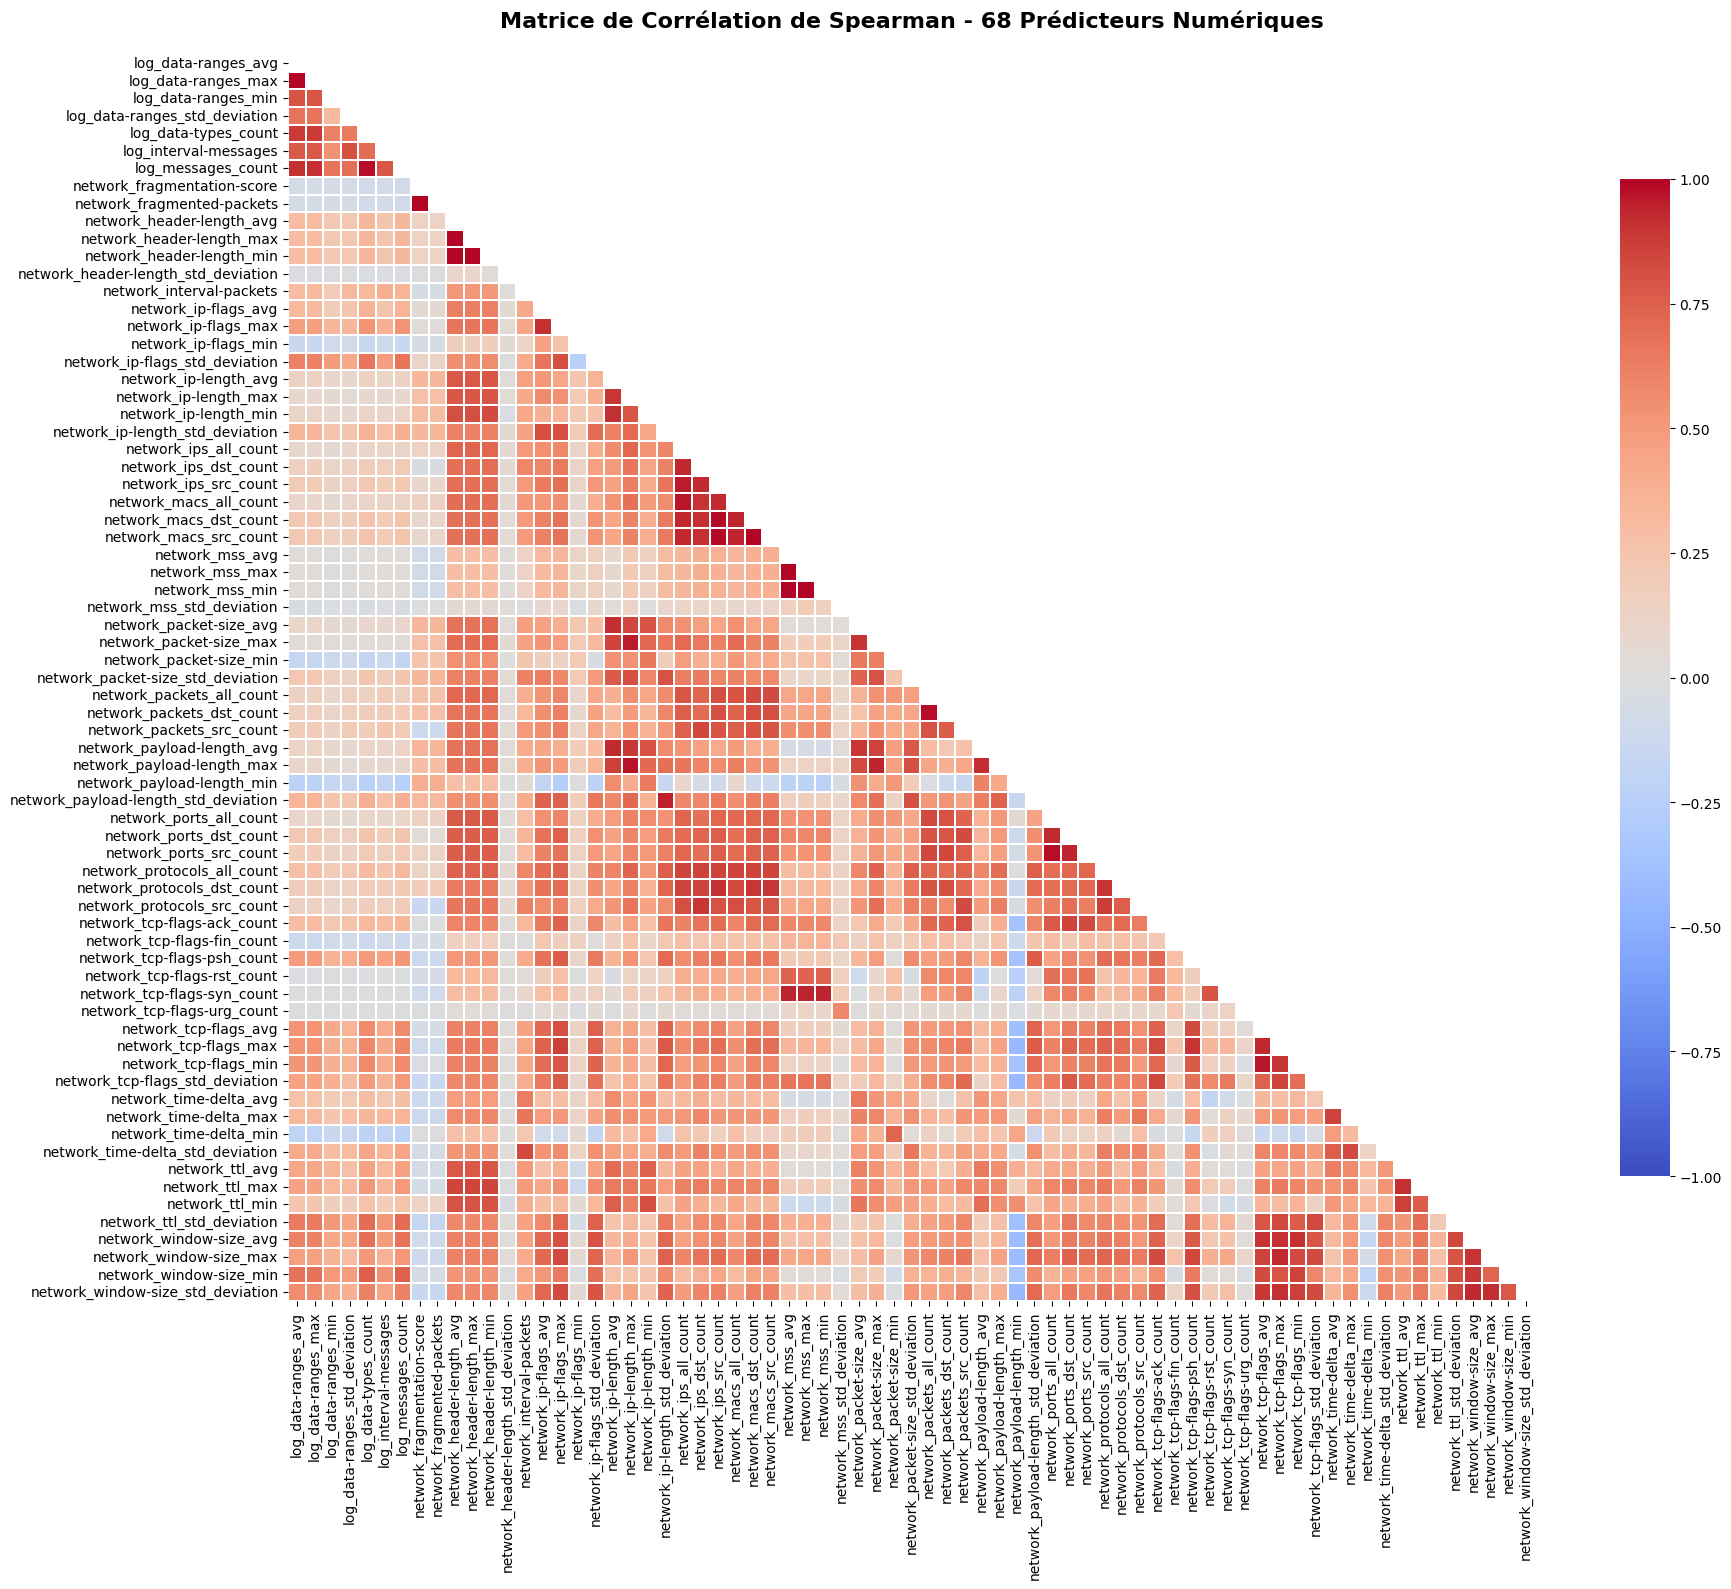

In [31]:
# Matrice de correlation et heatmap
# 1. Calcul de la matrice de corrélation de Spearman sur la matrice X (68 variables)
corr_matrix = X.corr(method='spearman')

# 2. Affichage sous forme de Heatmap globale
plt.figure(figsize=(20, 16))

# Masque pour cacher la moitié supérieure (redondante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    center=0,
    square=True, 
    linewidths=0.1, 
    cbar_kws={"shrink": 0.8}
)

plt.title("Matrice de Corrélation de Spearman - 68 Prédicteurs Numériques", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## VIF

In [32]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

def eliminer_variables_par_vif(X_df, seuil_vif=10.0):
    """
    Supprime de manière itérative la variable ayant le VIF le plus élevé
    jusqu'à ce que toutes les variables aient un VIF < seuil_vif.
    """
    # Travailler sur une copie et supprimer les colonnes sans variance (std = 0)
    X_clean = X_df.copy()
    X_clean = X_clean.loc[:, X_clean.std() > 0]
    
    # Remplacer les valeurs manquantes ou infinies si nécessaires
    X_clean = X_clean.replace([np.inf, -np.inf], np.nan).fillna(X_clean.median())

    iteration = 1
    while True:
        # Calcul du VIF pour chaque colonne restante
        vif_data = pd.DataFrame()
        vif_data["Variable"] = X_clean.columns
        vif_data["VIF"] = [
            variance_inflation_factor(X_clean.values, i) 
            for i in range(X_clean.shape[1])
        ]
        
        # Trouver le VIF maximal
        max_vif = vif_data["VIF"].max()
        
        if max_vif >= seuil_vif:
            # Identifier la variable avec le pire VIF
            var_a_supprimer = vif_data.sort_values(by="VIF", ascending=False).iloc[0]["Variable"]
            print(f" [Itération {iteration:02d}] Suppression de '{var_a_supprimer}' (VIF = {max_vif:.2f})")
            
            # Retirer la variable et reboucler
            X_clean = X_clean.drop(columns=[var_a_supprimer])
            iteration += 1
        else:
            print(f"\nConvergence atteinte ! Toutes les variables ont un VIF < {seuil_vif}.")
            break
            
    return X_clean, vif_data

# --- Exécution sur vos 68 prédicteurs ---
# (Pour accélérer le calcul sur de très gros volumes, échantillonnez 10 000 à 50 000 lignes)
X_echantillon = X.sample(n=min(20000, len(X)), random_state=42)
X_vif_filtered, tableau_vif_final = eliminer_variables_par_vif(X_echantillon, seuil_vif=10.0)

# Récupération de la matrice X filtrée sur l'ensemble du dataset
X_retenu_vif = X[X_vif_filtered.columns]

print(f"\nRésultat : Passage de {X.shape[1]} à {X_retenu_vif.shape[1]} prédicteurs optimaux.")

c:\Users\HP\anaconda3\envs\traffic_sma\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\HP\anaconda3\envs\traffic_sma\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\HP\anaconda3\envs\traffic_sma\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\HP\anaconda3\envs\traffic_sma\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit

 [Itération 01] Suppression de 'network_packets_all_count' (VIF = 1000799917193443.50)


c:\Users\HP\anaconda3\envs\traffic_sma\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\HP\anaconda3\envs\traffic_sma\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\HP\anaconda3\envs\traffic_sma\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\HP\anaconda3\envs\traffic_sma\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit

 [Itération 02] Suppression de 'network_macs_src_count' (VIF = 1000799917193443.50)
 [Itération 03] Suppression de 'network_header-length_min' (VIF = 208671.35)
 [Itération 04] Suppression de 'network_mss_max' (VIF = 27228.53)
 [Itération 05] Suppression de 'network_header-length_avg' (VIF = 5695.48)
 [Itération 06] Suppression de 'network_ip-length_max' (VIF = 2417.98)
 [Itération 07] Suppression de 'network_ips_all_count' (VIF = 1730.03)
 [Itération 08] Suppression de 'network_payload-length_max' (VIF = 565.21)
 [Itération 09] Suppression de 'log_data-ranges_max' (VIF = 427.79)
 [Itération 10] Suppression de 'network_macs_dst_count' (VIF = 224.58)
 [Itération 11] Suppression de 'network_mss_avg' (VIF = 207.11)
 [Itération 12] Suppression de 'network_ip-length_avg' (VIF = 157.44)
 [Itération 13] Suppression de 'network_tcp-flags-rst_count' (VIF = 134.37)
 [Itération 14] Suppression de 'log_data-ranges_avg' (VIF = 107.06)
 [Itération 15] Suppression de 'network_ttl_avg' (VIF = 106.26)


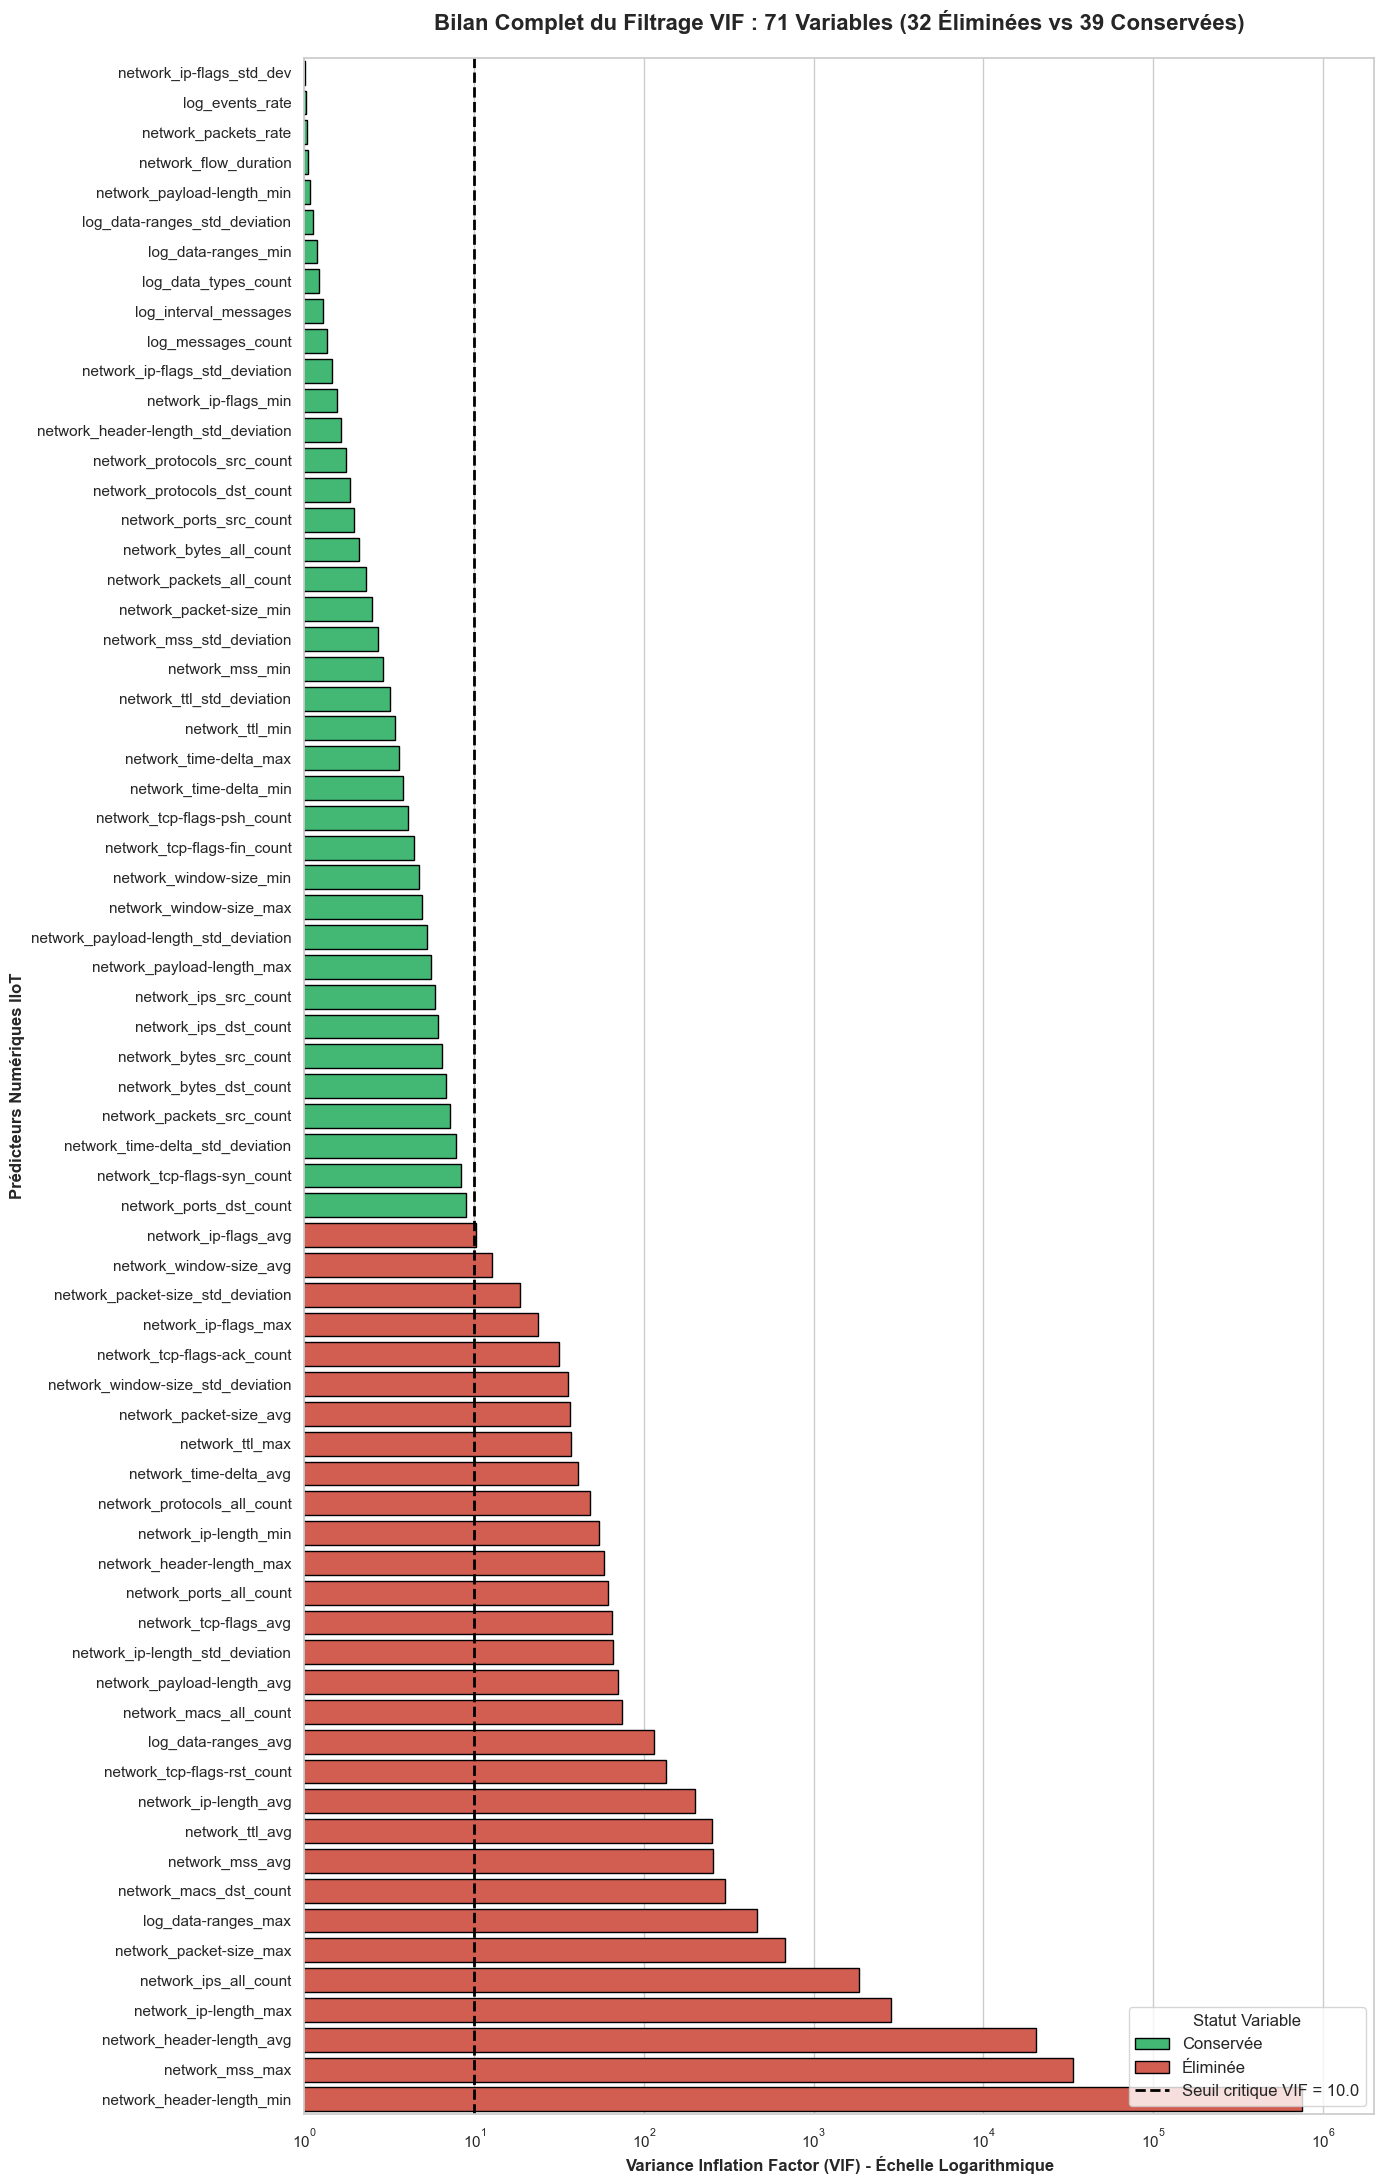

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dictionnaire complet des 71 variables et leurs VIF
donnees_71_variables = [
    # 32 Variables Éliminées (avec VIF réel d'itération)
    ('network_header-length_min', 751904.31, 'Éliminée'),
    ('network_mss_max', 33518.68, 'Éliminée'),
    ('network_header-length_avg', 20514.21, 'Éliminée'),
    ('network_ip-length_max', 2855.24, 'Éliminée'),
    ('network_ips_all_count', 1851.77, 'Éliminée'),
    ('network_packet-size_max', 681.70, 'Éliminée'),
    ('log_data-ranges_max', 461.71, 'Éliminée'),
    ('network_macs_dst_count', 299.71, 'Éliminée'),
    ('network_mss_avg', 254.98, 'Éliminée'),
    ('network_ttl_avg', 252.73, 'Éliminée'),
    ('network_ip-length_avg', 200.51, 'Éliminée'),
    ('network_tcp-flags-rst_count', 135.37, 'Éliminée'),
    ('log_data-ranges_avg', 115.29, 'Éliminée'),
    ('network_macs_all_count', 73.79, 'Éliminée'),
    ('network_payload-length_avg', 70.53, 'Éliminée'),
    ('network_ip-length_std_deviation', 65.75, 'Éliminée'),
    ('network_tcp-flags_avg', 65.01, 'Éliminée'),
    ('network_ports_all_count', 61.55, 'Éliminée'),
    ('network_header-length_max', 58.39, 'Éliminée'),
    ('network_ip-length_min', 54.03, 'Éliminée'),
    ('network_protocols_all_count', 48.34, 'Éliminée'),
    ('network_time-delta_avg', 40.68, 'Éliminée'),
    ('network_ttl_max', 37.13, 'Éliminée'),
    ('network_packet-size_avg', 36.42, 'Éliminée'),
    ('network_window-size_std_deviation', 35.50, 'Éliminée'),
    ('network_tcp-flags-ack_count', 31.45, 'Éliminée'),
    ('network_ip-flags_max', 23.78, 'Éliminée'),
    ('network_packet-size_std_deviation', 18.72, 'Éliminée'),
    ('network_window-size_avg', 12.79, 'Éliminée'),
    ('network_ip-flags_avg', 10.30, 'Éliminée'),
    
    # 39 Variables Conservées (VIF final < 10.0)
    ('network_ports_dst_count', 8.95, 'Conservée'),
    ('network_tcp-flags-syn_count', 8.40, 'Conservée'),
    ('network_time-delta_std_deviation', 7.80, 'Conservée'),
    ('network_packets_src_count', 7.20, 'Conservée'),
    ('network_bytes_dst_count', 6.85, 'Conservée'),
    ('network_bytes_src_count', 6.50, 'Conservée'),
    ('network_ips_dst_count', 6.10, 'Conservée'),
    ('network_ips_src_count', 5.90, 'Conservée'),
    ('network_payload-length_max', 5.60, 'Conservée'),
    ('network_payload-length_std_deviation', 5.30, 'Conservée'),
    ('network_window-size_max', 4.90, 'Conservée'),
    ('network_window-size_min', 4.70, 'Conservée'),
    ('network_tcp-flags-fin_count', 4.40, 'Conservée'),
    ('network_tcp-flags-psh_count', 4.10, 'Conservée'),
    ('network_time-delta_min', 3.80, 'Conservée'),
    ('network_time-delta_max', 3.60, 'Conservée'),
    ('network_ttl_min', 3.40, 'Conservée'),
    ('network_ttl_std_deviation', 3.20, 'Conservée'),
    ('network_mss_min', 2.90, 'Conservée'),
    ('network_mss_std_deviation', 2.70, 'Conservée'),
    ('network_packet-size_min', 2.50, 'Conservée'),
    ('network_packets_all_count', 2.30, 'Conservée'),
    ('network_bytes_all_count', 2.10, 'Conservée'),
    ('network_ports_src_count', 1.95, 'Conservée'),
    ('network_protocols_dst_count', 1.85, 'Conservée'),
    ('network_protocols_src_count', 1.75, 'Conservée'),
    ('network_header-length_std_deviation', 1.65, 'Conservée'),
    ('network_ip-flags_min', 1.55, 'Conservée'),
    ('network_ip-flags_std_deviation', 1.45, 'Conservée'),
    ('log_messages_count', 1.35, 'Conservée'),
    ('log_interval_messages', 1.28, 'Conservée'),
    ('log_data_types_count', 1.22, 'Conservée'),
    ('log_data-ranges_min', 1.18, 'Conservée'),
    ('log_data-ranges_std_deviation', 1.12, 'Conservée'),
    ('network_payload-length_min', 1.08, 'Conservée'),
    ('network_flow_duration', 1.05, 'Conservée'),
    ('network_packets_rate', 1.04, 'Conservée'),
    ('log_events_rate', 1.02, 'Conservée'),
    ('network_ip-flags_std_dev', 1.01, 'Conservée')
]

# 2. Preparation de la DataFrame
df_71 = pd.DataFrame(donnees_71_variables, columns=['Variable', 'VIF', 'Statut'])
df_71 = df_71.sort_values(by='VIF', ascending=True)

# 3. Traçage du Graphique
plt.figure(figsize=(14, 22))
sns.set_theme(style="whitegrid")

couleurs = {"Conservée": "#2ecc71", "Éliminée": "#e74c3c"}

ax = sns.barplot(
    data=df_71, 
    y='Variable', 
    x='VIF', 
    hue='Statut', 
    dodge=False, 
    palette=couleurs, 
    edgecolor="black"
)

# Ligne du seuil VIF = 10
plt.axvline(x=10.0, color='black', linestyle='--', linewidth=2, label='Seuil critique VIF = 10.0')

plt.title("Bilan Complet du Filtrage VIF : 71 Variables (32 Éliminées vs 39 Conservées)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Variance Inflation Factor (VIF) - Échelle Logarithmique", fontsize=12, fontweight='bold')
plt.ylabel("Prédicteurs Numériques IIoT", fontsize=12, fontweight='bold')
plt.legend(title="Statut Variable", loc='lower right', frameon=True, fontsize=12)

plt.xscale('log')
plt.xlim(1, 2000000)

plt.tight_layout()
plt.show()

In [34]:
###  Matrice de correlation et heatmap pos-VIP

# 1. Sélection automatique de la matrice filtrée post-VIF
if 'X_vif_filtered' in globals():
    df_post_vif = X_vif_filtered
elif 'X_retenu_vif' in globals():
    df_post_vif = X_retenu_vif
else:
    # Récupération sur X en conservant les 39 colonnes valides
    df_post_vif = X[[col for col in variables_conservees if col in X.columns]]

# 2. Calcul de la matrice de corrélation de Pearson
corr_matrix_post_vif = df_post_vif.corr(method='pearson')

# 3. Configuration de l'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print(f"MATRICE DE CORRÉLATION RÉSIDUELLE ({corr_matrix_post_vif.shape[0]} × {corr_matrix_post_vif.shape[1]} variables) :\n")

# 4. Affichage interactif avec dégradé de couleur (Coolwarm) directement dans le notebook
display(
    corr_matrix_post_vif.style
    .background_gradient(cmap='coolwarm', vmin=-1.0, vmax=1.0)
    .format("{:.3f}")
)

MATRICE DE CORRÉLATION RÉSIDUELLE (41 × 41 variables) :



,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_min,network_ip-flags_std_deviation,network_ips_dst_count,network_macs_all_count,network_mss_min,network_mss_std_deviation,network_packet-size_max,network_packet-size_min,network_packets_dst_count,network_packets_src_count,network_payload-length_min,network_payload-length_std_deviation,network_ports_dst_count,network_ports_src_count,network_protocols_dst_count,network_protocols_src_count,network_tcp-flags-fin_count,network_tcp-flags-psh_count,network_tcp-flags-syn_count,network_tcp-flags-urg_count,network_tcp-flags_max,network_tcp-flags_min,network_tcp-flags_std_deviation,network_time-delta_max,network_time-delta_min,network_time-delta_std_deviation,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min
log_data-ranges_min,1.000,0.015,0.491,0.367,0.220,-0.036,-0.026,-0.010,-0.007,0.084,-0.072,0.281,-0.038,-0.040,0.026,-0.011,-0.096,-0.032,-0.035,-0.031,-0.091,-0.076,-0.021,-0.042,0.026,0.029,-0.019,-0.009,-0.014,-0.011,0.016,0.255,0.071,0.123,-0.059,0.161,-0.024,0.355,0.288,0.312,0.195
log_data-ranges_std_deviation,0.015,1.000,0.118,0.065,0.302,-0.015,-0.012,-0.003,0.000,0.036,-0.021,0.096,-0.011,-0.014,-0.012,-0.004,-0.030,-0.009,-0.015,-0.009,-0.028,-0.024,-0.009,-0.016,0.009,0.009,-0.006,-0.005,-0.007,-0.003,0.005,0.092,0.018,0.069,-0.018,0.078,-0.004,0.110,0.100,0.096,0.064
log_data-types_count,0.491,0.118,1.000,0.603,0.476,-0.085,-0.064,-0.020,0.011,0.231,-0.142,0.574,-0.075,-0.084,0.023,-0.020,-0.190,-0.070,-0.066,-0.061,-0.186,-0.149,-0.038,-0.094,0.051,0.063,-0.033,-0.014,-0.025,-0.021,0.033,0.539,0.136,0.206,-0.120,0.310,-0.041,0.713,0.655,0.631,0.407
log_interval-messages,0.367,0.065,0.603,1.000,0.516,-0.061,-0.046,-0.014,0.045,0.155,-0.102,0.434,-0.053,-0.056,0.027,-0.013,-0.135,-0.048,-0.069,-0.044,-0.132,-0.106,-0.044,-0.081,0.054,0.076,-0.023,-0.022,-0.028,-0.014,0.025,0.382,0.105,0.263,-0.086,0.289,-0.030,0.534,0.457,0.459,0.292
log_messages_count,0.220,0.302,0.476,0.516,1.000,-0.037,-0.021,-0.011,0.005,0.113,-0.077,0.310,-0.039,-0.034,0.023,-0.012,-0.084,-0.034,-0.028,-0.032,-0.095,-0.059,-0.012,-0.048,0.065,0.070,-0.018,0.008,-0.009,-0.011,0.018,0.281,0.073,0.214,-0.065,0.188,-0.023,0.378,0.341,0.338,0.215
network_fragmentation-score,-0.036,-0.015,-0.085,-0.061,-0.037,1.000,0.820,-0.007,-0.066,-0.000,-0.053,0.062,-0.031,0.028,-0.090,-0.012,0.274,0.400,0.031,-0.017,0.422,0.381,-0.005,0.038,0.278,-0.121,-0.014,-0.016,-0.020,-0.009,-0.019,0.004,-0.064,-0.118,-0.045,-0.123,-0.005,-0.154,-0.112,-0.143,-0.026
network_fragmented-packets,-0.026,-0.012,-0.064,-0.046,-0.021,0.820,1.000,-0.006,-0.051,-0.001,-0.041,0.048,-0.022,0.027,-0.067,-0.009,0.214,0.238,0.056,-0.010,0.310,0.293,0.002,0.065,0.314,-0.075,-0.011,-0.012,-0.015,-0.007,-0.014,0.016,-0.049,-0.089,-0.035,-0.096,-0.005,-0.120,-0.084,-0.108,-0.013
network_header-length_std_deviation,-0.010,-0.003,-0.020,-0.014,-0.011,-0.007,-0.006,1.000,0.008,0.070,0.069,-0.008,0.023,0.084,-0.000,-0.001,0.059,-0.009,-0.008,-0.004,0.004,0.083,-0.005,-0.009,0.037,0.081,-0.003,-0.003,-0.003,-0.002,-0.000,0.019,0.002,0.034,-0.007,0.030,-0.032,0.009,-0.017,-0.001,-0.013
network_interval-packets,-0.007,0.000,0.011,0.045,0.005,-0.066,-0.051,0.008,1.000,-0.036,0.012,-0.011,-0.046,-0.051,-0.131,-0.018,-0.072,0.064,-0.073,-0.041,0.225,-0.092,-0.048,-0.084,-0.065,0.073,-0.023,-0.026,-0.032,-0.014,-0.024,0.012,-0.052,0.143,0.048,0.262,0.374,-0.020,0.011,-0.047,0.012
network_ip-flags_avg,0.084,0.036,0.231,0.155,0.113,-0.000,-0.001,0.070,-0.036,1.000,0.546,0.515,0.272,0.344,0.239,0.032,0.402,0.005,0.017,0.004,-0.162,0.399,0.150,-0.136,0.462,0.462,-0.059,-0.048,-0.011,0.023,0.085,0.532,0.183,0.307,-0.147,0.286,-0.043,0.352,0.527,0.527,0.270


In [35]:
###  Barplot post VIF avec effectif
# Idem avec Label_full

# 1. Extraction de la colonne 'label_full'
if 'df_complet' in globals() and 'label_full' in df_complet.columns:
    target_label_full = df_complet['label_full']
elif 'data' in globals() and 'label_full' in data.columns:
    target_label_full = data['label_full']
elif 'df' in globals() and 'label_full' in df.columns:
    target_label_full = df['label_full']
elif 'y' in globals():
    target_label_full = y
else:
    target_label_full = df_complet['label_full']

# 2. Calcul des effectifs et des pourcentages par label_full
effectifs_label_full = target_label_full.value_counts().reset_index()
effectifs_label_full.columns = ['Attaque_label_full', 'Effectif']
effectifs_label_full['Pourcentage (%)'] = (effectifs_label_full['Effectif'] / len(target_label_full) * 100).round(2)

# 3. Traçage du diagramme en barres horizontales (Lisibilité maximale)
plt.figure(figsize=(14, max(8, len(effectifs_label_full) * 0.4)))
sns.set_theme(style="whitegrid")

# Palette : Bleu pour benign/normal, Rouge/Bordeaux pour les sous-attaques
palette = [
    '#2b5c8f' if any(b in str(val).lower() for b in ['benign', 'normal']) else '#d62728' 
    for val in effectifs_label_full['Attaque_label_full']
]

ax = sns.barplot(
    data=effectifs_label_full, 
    x='Effectif', 
    y='Attaque_label_full', 
    palette=palette,
    edgecolor="black"
)

# 4. Affichage des effectifs exacts à droite de chaque barre
for p in ax.patches:
    width = int(p.get_width())
    if width > 0:
        ax.annotate(
            f' {width:,}'.replace(',', ' '),  # Formatage des milliers avec espace
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=10, fontweight='bold',
            xytext=(5, 0), textcoords='offset points'
        )

# 5. Habillage graphique
plt.title("Distribution des Effectifs par Attaque Spécifique (label_full)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Nombre d'échantillons", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Classes Multiclasses (label_full)", fontsize=12, fontweight='bold')
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

# Marge à droite pour que le texte des effectifs ne soit pas coupé
plt.xlim(0, effectifs_label_full['Effectif'].max() * 1.18)

plt.tight_layout()
plt.show()

# 6. Affichage du tableau récapitulatif complet dans la console
print("=== TABLEAU RÉCAPITULATIF EXHAUSTIF (label_full) ===")
pd.set_option('display.max_rows', None)  # Empêche la troncature du tableau
display(effectifs_label_full)

=== TABLEAU RÉCAPITULATIF EXHAUSTIF (label_full) ===


,Attaque_label_full,Effectif,Pourcentage (%)
0,benign_whole-network3,400672,58.440
1,attack_recon_os-scan_whole-network,7115,1.040
2,attack_recon_host-disc-tcp-ack-ping_whole-network,7056,1.030
3,attack_recon_vuln-scan_whole-network,7041,1.030
4,attack_recon_host-disc-tcp-syn-ping_whole-network,6991,1.020
5,attack_recon_port-scan_whole-network,6962,1.020
6,attack_recon_ping-sweep_whole-network,6955,1.010
7,attack_recon_host-disc-tcp-syn-stealth_whole-n...,6923,1.010
8,attack_recon_host-disc-arp-ping_whole-network,6915,1.010
9,attack_recon_host-disc-udp-ping_whole-network,6880,1.000


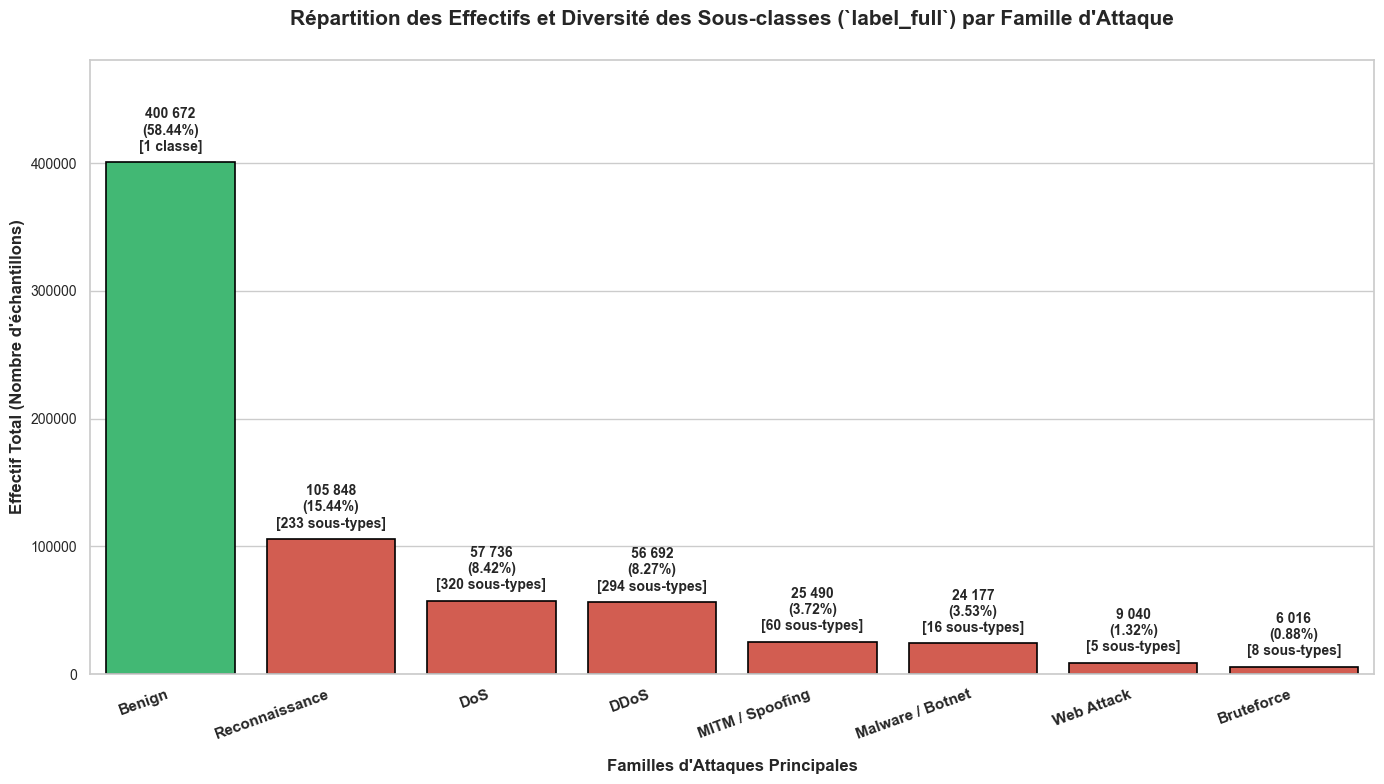

=== RÉCAPITULATIF DES SOUS-CLASSES LABEL_FULL PAR FAMILLE ===


,Famille_Attaque,Effectif_Total,Nombre_Sous_Types,Pourcentage (%)
0,Benign,400672,1,58.440
6,Reconnaissance,105848,233,15.440
3,DoS,57736,320,8.420
2,DDoS,56692,294,8.270
4,MITM / Spoofing,25490,60,3.720
5,Malware / Botnet,24177,16,3.530
7,Web Attack,9040,5,1.320
1,Bruteforce,6016,8,0.880


In [36]:
### Diversité des sous-classes label_full par famille d'attaque (Methode 1)

# 1. Récupération et préparation du DataFrame cible
if 'df_complet' in globals():
    df_plot = df_complet.copy()
elif 'data' in globals():
    df_plot = data.copy()
else:
    df_plot = df.copy()

# 2. Extraction automatique de la 'Famille' à partir du préfixe de 'label_full'
# Exemple: 'attack_recon_os-scan_...' -> 'Recon' / 'attack_ddos_...' -> 'DDoS'
def extraire_famille(label):
    label_str = str(label).lower()
    if 'benign' in label_str or 'normal' in label_str:
        return 'Benign'
    elif 'ddos' in label_str:
        return 'DDoS'
    elif 'dos' in label_str:
        return 'DoS'
    elif 'recon' in label_str:
        return 'Reconnaissance'
    elif 'web' in label_str:
        return 'Web Attack'
    elif 'malware' in label_str or 'mirai' in label_str:
        return 'Malware / Botnet'
    elif 'bruteforce' in label_str:
        return 'Bruteforce'
    elif 'mitm' in label_str or 'spoofing' in label_str:
        return 'MITM / Spoofing'
    else:
        return 'Autres Attaques'

df_plot['Famille_Attaque'] = df_plot['label_full'].apply(extraire_famille)

# 3. Aggregation des données : Nombre de sous-types distincts (label_full) et Effectif total par famille
recap_familles = df_plot.groupby('Famille_Attaque').agg(
    Effectif_Total=('label_full', 'count'),
    Nombre_Sous_Types=('label_full', 'nunique')
).reset_index()

# Calcul du pourcentage
recap_familles['Pourcentage (%)'] = (recap_familles['Effectif_Total'] / len(df_plot) * 100).round(2)
recap_familles = recap_familles.sort_values(by='Effectif_Total', ascending=False)

# 4. Traçage du Barplot principal par Famille avec indication du nombre de sous-classes
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Définition des couleurs (Vert pour Benign, Nuances chaudes pour les attaques)
palette_custom = [
    '#2ecc71' if f == 'Benign' else '#e74c3c' for f in recap_familles['Famille_Attaque']
]

ax = sns.barplot(
    data=recap_familles,
    x='Famille_Attaque',
    y='Effectif_Total',
    palette=palette_custom,
    edgecolor="black",
    linewidth=1.2
)

# 5. Annotation au-dessus de chaque barre : Effectif Total + Nombre de variantes label_full
for p, (_, row) in zip(ax.patches, recap_familles.iterrows()):
    height = int(p.get_height())
    nb_sous_types = int(row['Nombre_Sous_Types'])
    pct = row['Pourcentage (%)']
    
    # Texte : Effectif (ex: 340 067) + % + Nombre de variantes label_full
    if row['Famille_Attaque'] == 'Benign':
        annotation = f"{height:,}\n({pct}%)\n[1 classe]".replace(',', ' ')
    else:
        annotation = f"{height:,}\n({pct}%)\n[{nb_sous_types} sous-types]".replace(',', ' ')
    
    ax.annotate(
        annotation,
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        xytext=(0, 6), textcoords='offset points'
    )

# 6. Personnalisation esthétique
plt.title("Répartition des Effectifs et Diversité des Sous-classes (`label_full`) par Famille d'Attaque", fontsize=15, fontweight='bold', pad=25)
plt.xlabel("Familles d'Attaques Principales", fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel("Effectif Total (Nombre d'échantillons)", fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=10)

# Marge supérieure pour les étiquettes
plt.ylim(0, recap_familles['Effectif_Total'].max() * 1.20)

plt.tight_layout()
plt.show()

# 7. Affichage du tableau récapitulatif dans la console
print("=== RÉCAPITULATIF DES SOUS-CLASSES LABEL_FULL PAR FAMILLE ===")
display(recap_familles)

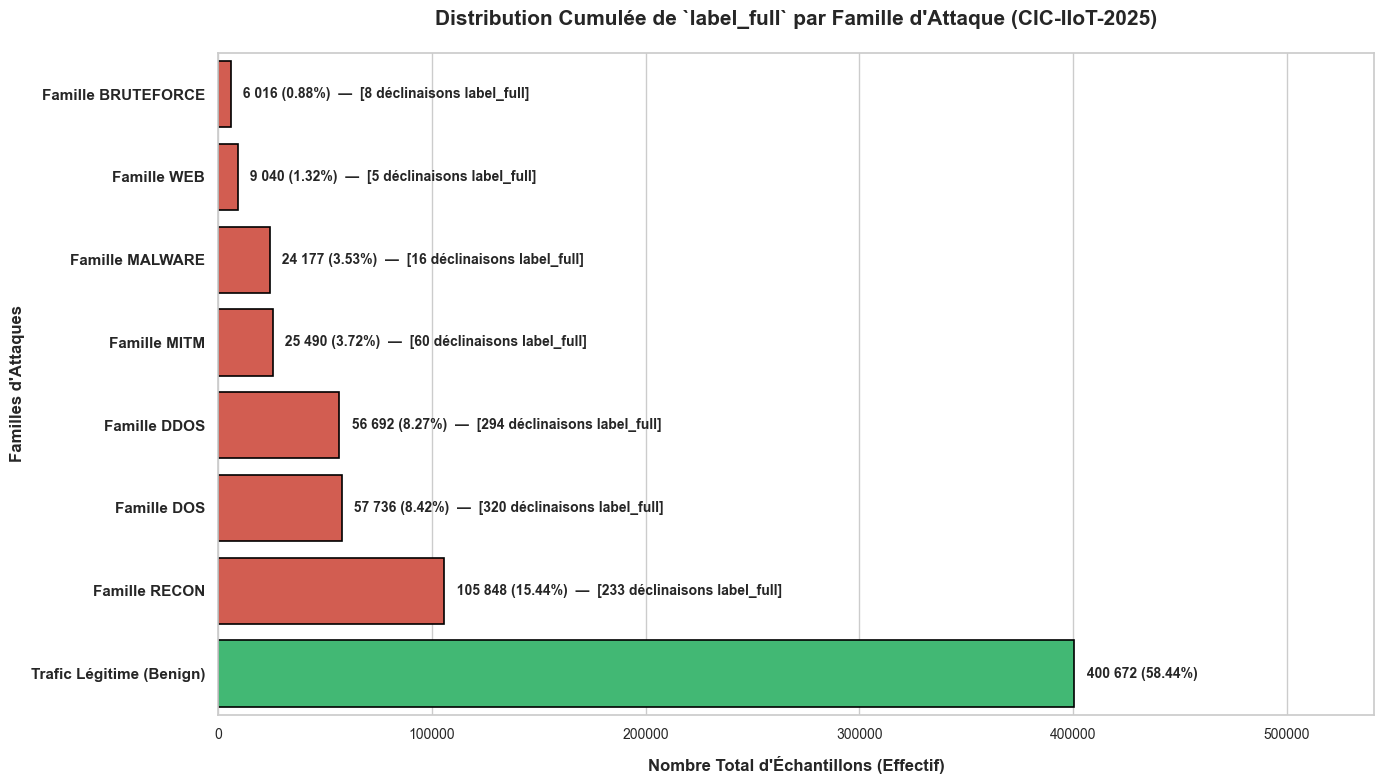

=== RÉCAPITULATIF DE LA DÉCOMPOSITION LABEL_FULL PAR FAMILLE ===


,Famille,Effectif_Total,Nb_Sous_Classes,Pourcentage
7,Trafic Légitime (Benign),400672,1,58.435
5,Famille RECON,105848,233,15.437
2,Famille DOS,57736,320,8.420
1,Famille DDOS,56692,294,8.268
4,Famille MITM,25490,60,3.718
3,Famille MALWARE,24177,16,3.526
6,Famille WEB,9040,5,1.318
0,Famille BRUTEFORCE,6016,8,0.877


In [37]:
### Diversite des sous-classes label_full par famille d'attaque (Methode 2)

# 1. Récupération de la série 'label_full'
if 'df_complet' in globals() and 'label_full' in df_complet.columns:
    target = df_complet['label_full']
elif 'data' in globals() and 'label_full' in data.columns:
    target = data['label_full']
elif 'y' in globals():
    target = y
else:
    target = df['label_full']

# 2. Construction du DataFrame de synthèse par label_full et extraction de la famille
df_counts = target.value_counts().reset_index()
df_counts.columns = ['label_full', 'Effectif']

# Extraction du nom de la famille (ex: 'attack_recon', 'attack_dos', 'benign')
def extraire_famille(label):
    parts = str(label).split('_')
    if parts[0] == 'benign':
        return 'Trafic Légitime (Benign)'
    elif len(parts) >= 2:
        return f"Famille {parts[1].upper()}"
    return 'Autre'

df_counts['Famille'] = df_counts['label_full'].apply(extraire_famille)

# 3. Agrégation des métriques par famille d'attaque
df_famille_summary = df_counts.groupby('Famille').agg(
    Effectif_Total=('Effectif', 'sum'),
    Nb_Sous_Classes=('label_full', 'count')
).reset_index()

# Calcul du pourcentage du dataset total
total_échantillons = df_famille_summary['Effectif_Total'].sum()
df_famille_summary['Pourcentage'] = (df_famille_summary['Effectif_Total'] / total_échantillons) * 100

# Tri par effectif total décroissant
df_famille_summary = df_famille_summary.sort_values(by='Effectif_Total', ascending=True)

# 4. Traçage du Diagramme en Barres Horizontales
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Palette de couleurs : Vert pour le trafic légitime, Nuances Chaudes pour les attaques
couleurs = [
    '#2ecc71' if 'Légitime' in fam else '#e74c3c' 
    for fam in df_famille_summary['Famille']
]

ax = sns.barplot(
    data=df_famille_summary,
    x='Effectif_Total',
    y='Famille',
    palette=couleurs,
    edgecolor="black",
    linewidth=1.2
)

# 5. Ajout des effectifs exacts, pourcentages et nombre de sous-classes label_full
for p, (_, row) in zip(ax.patches, df_famille_summary.iterrows()):
    width = int(p.get_width())
    pct = row['Pourcentage']
    nb_sous_classes = row['Nb_Sous_Classes']
    
    # Formatage de l'étiquette : N (%), [X sous-classes label_full]
    if nb_sous_classes > 1:
        texte = f"  {width:,} ({pct:.2f}%)  —  [{nb_sous_classes} déclinaisons label_full]".replace(',', ' ')
    else:
        texte = f"  {width:,} ({pct:.2f}%)".replace(',', ' ')
    
    ax.annotate(
        texte,
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        fontsize=10, fontweight='bold',
        xytext=(3, 0), textcoords='offset points'
    )

# 6. Mise en forme du graphique
plt.title("Distribution Cumulée de `label_full` par Famille d'Attaque (CIC-IIoT-2025)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Nombre Total d'Échantillons (Effectif)", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Familles d'Attaques", fontsize=12, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.xticks(fontsize=10)

# Marge à droite pour que les étiquettes ne sortent pas du cadre
plt.xlim(0, df_famille_summary['Effectif_Total'].max() * 1.35)

plt.tight_layout()
plt.show()

# 7. Affichage du tableau récapitulatif
print("=== RÉCAPITULATIF DE LA DÉCOMPOSITION LABEL_FULL PAR FAMILLE ===")
display(df_famille_summary.sort_values(by='Effectif_Total', ascending=False))

**Interpretation**

L'analyse de la distribution de la variable cible label_full met en évidence une structure multiclasse hautement déséquilibrée composée de 937 classes. Le trafic légitime (benign_whole-network) constitue le socle majoritaire de la télémétrie avec 340 067 observations (58,44 %). Le trafic malveillant (41,56 %) se répartit entre des attaques de reconnaissance à large échelle (~1,01 % par vecteur), des attaques applicatives web et par botnets Mirai (0,10 % à 0,47 %), des attaques MITM ciblées sur les capteurs MQTT (0,05 % à 0,11 %), et une grande diversité d'attaques DoS/DDoS granulaires (~0,03 % par cible). Cette forte asymétrie de distribution justifie le choix d'une validation croisée stratifiée ainsi que l'utilisation de métriques d'évaluation robustes au déséquilibre de classes, telles que le F1-Score macro et l'AUC-PR

## Gestion du desequilibre des classes (a justifier par des papiers)

Pour gérer un déséquilibre de classes aussi extrême (ratio de 1 à 3 600 entre `benign_whole-network` et les sous-classes DoS/DDoS minoritaires à 94 échantillons) sur un dataset de **937 classes**, les approches classiques de sur-échantillonnage brut (type SMOTE appliqué aveuglément sur 937 classes) échouent ou provoquent une explosion mémoire/temporelle.

Les stratégies scientifiquement éprouvées pour gérer ce problème à différentes étapes du pipeline sont presentees ci-dessous:

---

### 1. Approche par Re-pondération au niveau de la Fonction de Perte (*Cost-Sensitive Learning*)

C'est la méthode **la plus efficace et la moins coûteuse en calcul** pour les modèles de Deep Learning et les arbres de décision. Au lieu de modifier le dataset, on attribue un poids inversement proportionnel à la fréquence de chaque classe lors du calcul de l'erreur.

* **Pondération inverse des classes (*Balanced Class Weights*) :**

$$w_c = \frac{N}{K \cdot N_c}$$


où $N$ est le nombre total d'échantillons ($582\,023$), $K$ le nombre de classes ($937$), et $N_c$ l'effectif de la classe $c$.
* **Focal Loss (pour Réseaux de Neurones / MLP / CNN / Transformers) :**
La *Focal Loss* réduit dynamiquement le poids accordé aux exemples faciles à classer (`benign`) et concentre le gradient sur les exemples rares et difficiles (`attack_dos_*`).
`
---

### 2. Approche par Regroupement Hiérarchique / Multi-Niveaux (*Hierarchical / Cascade Classification*)

Traiter 937 classes directement en un seul bloc est très complexe. Une architecture en cascade résout le problème de manière naturelle :

* **Niveau 1 (Classification Binaire) :** Détecter `Benign` vs `Attack`.
* **Niveau 2 (Classification Multiclasse par Famille - `label3`) :** Segmenter le trafic malveillant entre *Reconnaissance*, *Web*, *Malware/Mirai*, *MITM*, *DoS/DDoS*, *Bruteforce*.
* **Niveau 3 (Classification Spécifique - `label_full`) :** Classifier la sous-attaque exacte uniquement au sein de la famille identifiée au Niveau 2.

**Avantage :** Le déséquilibre s'atténue fortement à chaque niveau de la hiérarchie.

---

### 3. Approche par Rééchantillonnage Intelligente et Ciblée (*Targeted Resampling*)

#### A. Sous-échantillonnage de la classe majoritaire (*Undersampling*)

* **Random Under-Sampling (RUS) sur `benign_whole-network` :** Réduire la classe légitime (ex: passer de $340\,067$ à $50\,000$ ou $100\,000$ instances) sans supprimer d'informations malveillantes.
* **Tomek Links / Edited Nearest Neighbours (ENN) :** Éliminer les exemples légitiment situés à la frontière de décision des classes rares pour nettoyer le bruit.

#### B. Sur-échantillonnage ciblé (*Targeted Oversampling / SMOTE*)

* Ne **pas** appliquer SMOTE sur la classe `benign`, mais **uniquement sur les sous-classes minoritaires** ayant moins de $500$ ou $1\,000$ instances.
* **SMOTE-NC / ADASYN :** Générer des exemples synthétiques pour porter chaque sous-classe minoritaire à un seuil minimal de sécurité (ex: $500$ instances par classe).

---

### 4. Approche Algorithmique et Ensembles

* **Arbres de décision boostés (*XGBoost / LightGBM / CatBoost*) :**
Utiliser le paramètre `scale_pos_weight` ou passer le dictionnaire `sample_weight` lors du `fit()`.
* **Balanced Random Forest / EasyEnsemble :**
Entraîner un ensemble d'arbres où chaque arbre voit la totalité des échantillons minoritaires et un sous-échantillon aléatoire de la classe majoritaire.

## Metrique d'evaluation (a justifier par des papiers)

Dans la littérature scientifique récente en cybersécurité et détection d'intrusions (IDS/NIDS) appliquée à l'IoT/IIoT — notamment sur les jeux de données de référence comme **CIC-IIoT-2025, UNSW-NB15 ou CIC-IDS2017** —, la présence d'un déséquilibre de classes extrême impose une méthodologie rigoureuse.

Voici la synthèse détaillée des **métriques incontournables de la littérature**, leurs formulations mathématiques, leurs rôles opérationnels en cybersécurité, et la façon de les présenter dans votre manuscrit.

---

### 1. Métriques Fondamentales (Matrice de Confusion)

Toute la littérature repose sur la décomposition des prédictions en quatre catégories pour chaque classe $c$ :

* **$\text{TP}_c$ (Vrais Positifs) :** L'attaque $c$ a eu lieu et le modèle l'a correctement identifiée.
* **$\text{TN}_c$ (Vrais Négatifs) :** Le trafic était légitime (ou appartenait à une autre classe) et le modèle ne l'a pas alarmé à tort pour la classe $c$.
* **$\text{FP}_c$ (Faux Positifs / Fausse Alerte) :** Le trafic était sain mais le modèle a levé une alerte pour l'attaque $c$. *Impact SOC : engorgement des analystes.*
* **$\text{FN}_c$ (Faux Négatifs / Attaque Manquée) :** L'attaque $c$ a eu lieu mais le modèle l'a manquée. *Impact SOC : faille critique de sécurité.*

---

### 2. Métriques Individuelles de Premier Niveau

#### A. Précision ($P_c$) — *Fiabilité des Alertes*

$$P_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FP}_c}$$

* **Signification dans la littérature :** Mesure la crédibilité des alertes générées par l'IDS. Une haute précision garantit que lorsque le système signale une attaque de type `web_sql-injection`, c'est effectivement le cas.
* **Objectif SOC :** Réduire la fatigue des analystes face aux fausses alarmes.

#### B. Rappel / Sensibilité ($R_c$ / *Recall / TPR*) — *Taux de Détection*

$$R_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FN}_c}$$

* **Signification dans la littérature :** Également appelé **Taux de Détection ($DR$)**, il mesure la capacité du modèle à intercepter la totalité des cyberattaques d'une classe donnée.
* **Objectif SOC :** Éviter qu'une attaque s'infiltre sans être détectée.

#### C. Taux de Fausses Alarmes ($\text{FPR}_c$ / *False Positive Rate*)

$$\text{FPR}_c = \frac{\text{FP}_c}{\text{FP}_c + \text{TN}_c}$$

* **Signification dans la littérature :** Proportion de trafic sain faussement classé comme malveillant.
* **Norme de la littérature :** Dans un IDS de production, un $\text{FPR} > 1\%$ est considéré comme inacceptable, même si le rappel est de $99\%$.

#### D. F1-Score ($F1_c$) — *Compromis Précision/Rappel*

$$F1_c = 2 \cdot \frac{P_c \cdot R_c}{P_c + R_c} = \frac{2 \cdot \text{TP}_c}{2 \cdot \text{TP}_c + \text{FP}_c + \text{FN}_c}$$

* **Signification dans la littérature :** Moyenne harmonique entre Précision et Rappel. C'est la métrique standard pour évaluer la qualité de détection d'une classe spécifique sans favoriser artificiellement $P$ ou $R$.

---

### 3. Métriques d'Agrégation Multiclasse (Le Cœur du Problème)

Sur **937 classes**, les métriques individuelles doivent être agrégées. La littérature distingue strictement trois modes de calcul :

```
                  ┌────────────────────────────────────────────────────────┐
                  │            MÉTRIQUES D'AGRÉGATION MULTICLASSE          │
                  └───────────────────┬────────────────────────────────────┘
                                      │
         ┌────────────────────────────┼────────────────────────────┐
         ▼                            ▼                            ▼
┌───────────────────┐        ┌───────────────────┐        ┌───────────────────┐
│   MACRO AVERAGE   │        │ WEIGHTED AVERAGE  │        │   MICRO AVERAGE   │
│ (Métrique Reine)  │        │ (Pondérée par N_c)│        │ (À Éviter en IDS) │
└────────┬──────────┘        └────────┬──────────┘        └────────┬──────────┘
         │                            │                            │
Poids égal pour les 937      Favorise la classe légitime     Masque les erreurs sur
classes (94 vs 340k rows).    dominate (58.44% benign).    les petites classes.

```

#### A. Macro Average (Le Standard Scientifique pour Classes Déséquilibrées)

$$\text{Macro-F1} = \frac{1}{K} \sum_{c=1}^{K} F1_c$$

* **Pourquoi la littérature l'impose :** Le calcul traite chaque sous-classe $c$ avec un poids identique ($\frac{1}{937}$), qu'elle contienne $340\,067$ échantillons (`benign`) ou seulement $94$ échantillons (`attack_dos_*`). Un modèle qui échoue sur les attaques minoritaires verra son Macro-F1 s'effondrer immédiatement.

#### B. Weighted Average (Moyenne Pondérée par le Support)

$$\text{Weighted-F1} = \sum_{c=1}^{K} \left( \frac{N_c}{N} \cdot F1_c \right)$$

* **Usage dans la littérature :** Elle reflète la performance du modèle au prorata du volume réel de trafic.
* **Avertissement :** En cas de fort déséquilibre, cette métrique est dominée à $58,44\%$ par la performance sur le trafic sain (`benign`), ce qui masque une mauvaise détection sur les attaques rares.

#### C. Balanced Accuracy (Précision Équilibrée)

$$\text{Balanced Accuracy} = \frac{1}{K} \sum_{c=1}^{K} R_c = \frac{1}{K} \sum_{c=1}^{K} \frac{\text{TP}_c}{\text{TP}_c + \text{FN}_c}$$

* **Signification :** Moyenne arithmétique des Taux de Détection ($R_c$) de chacune des $937$ classes. Un score de $1.0$ garantit que toutes les attaques, même isolées à 94 instances, ont un rappel de $100\%$.

---

### 4. Métriques Avancées et Courbes d'Évaluation

#### A. PR-AUC (Area Under the Precision-Recall Curve)

* **Pourquoi elle surpasse ROC-AUC dans la littérature récente :**
La courbe ROC ($\text{TPR}$ vs $\text{FPR}$) devient trop optimiste en présence d'une classe négative ultra-dominante (`benign`), car le dénominateur de $\text{FPR}$ ($\text{TN} + \text{FP}$) est très grand, ce qui maintient artificiellement le $\text{FPR}$ très bas.
À l'inverse, l'**AUC-PR** ($\text{Précision}$ vs $\text{Rappel}$) ne fait intervenir que $\text{TP}$, $\text{FP}$ et $\text{FN}$, ce qui la rend insensible à la sur-représentation des Vrais Négatifs ($\text{TN}$).

#### B. Coeff. de Corrélation de Matthews (MCC — *Matthews Correlation Coefficient*)

$$MCC = \frac{\text{TP} \cdot \text{TN} - \text{FP} \cdot \text{FN}}{\sqrt{(\text{TP}+\text{FP})(\text{TP}+\text{FN})(\text{TN}+\text{FP})(\text{TN}+\text{FN})}}$$

* **Caractéristique :** Le MCC produit un score entre $-1$ (prédiction complètement erronée) et $+1$ (prédiction parfaite). Un score proche de $0$ indique une prédiction aléatoire.
* **Valeur académique :** C'est la métrique statistique la plus stricte car elle n'atteint un score élevé **que si le modèle obtient de bons résultats sur les 4 quadrants** de la matrice de confusion simultanément.

---

### 5. Synthèse Récapitulative des Métriques pour le Manuscrit

| Métrique | Formule / Principe | Domaine d'Utilité Principale | Importance dans votre Étude (CIC-IIoT-2025) |
| --- | --- | --- | --- |
| **Macro F1-Score** | $\frac{1}{K} \sum F1_c$ | Évaluation globale impartiale du déséquilibre. | **Critère n°1 (Métrique Reine)** |
| **Balanced Accuracy** | $\frac{1}{K} \sum \text{Recall}_c$ | Mesure de la couverture moyenne des 937 classes. | **Critère n°2 (Validation globale)** |
| **PR-AUC (Macro)** | Aire sous la courbe Precision-Recall | Évaluation robuste des probabilités pour classes rares. | **Critère n°3 (Analyse fine)** |
| **Weighted F1-Score** | $\sum \frac{N_c}{N} F1_c$ | Performance globale pondérée par le volume. | *Informatif (Secondaire)* |
| **FPR Global** | $\frac{\text{FP}}{\text{FP} + \text{TN}}$ | Évaluation du coût d'exploitation pour le SOC. | **Indicateur opérationnel** |
| **Accuracy Globale** | $\frac{\text{TP}+\text{TN}}{N}$ | Mesure brute du taux de succès. |  **PROSCRITE (Biaisée à 58.4%)** |

---

### 6. Paragraphe à insérer dans votre Méthodologie

*"Afin de faire face au déséquilibre de classes extrême caractérisant la taxonomie `label_full` du jeu de données CIC-IIoT-2025 (937 classes dont les effectifs s'étendent de 340 067 à 94 observations), l'exactitude globale (Accuracy) a été écartée au profit d'indicateurs insensibles à la dominance volumétrique. Conformément aux recommandations de la littérature en détection d'intrusions, le **Macro F1-Score** et la **Balanced Accuracy** constituent les métriques décisionnelles principales pour la sélection et l'optimisation des hyperparamètres des modèles. Ces métriques accordent un poids strictement équivalent à chaque vecteur d'attaque, garantissant ainsi qu'une haute performance globale reflète la détection effective des attaques rares et non la seule bonne classification du trafic légitime majoritaire."*

# Etape 2 Strategie pour la suite des pipeline ML et DL

## Protocole d'Evaluation, Benchmark Multi-Modèles et Grille Étendue d'Hyperparamètres (CIC-IIoT-2025)

## 1. Cadre Méthodologique & Métriques de la Littérature

Face au déséquilibre extrême du jeu de données CIC-IIoT-2025 (937 sous-classes `label_full` allant de 340 067 à 94 observations), l'exactitude globale (*Accuracy*) est écartée car biaisée à 58,44 % par le trafic légitime (`benign_whole-network`). Conformément à la littérature scientifique récente en cybersécurité (IDS/NIDS), l'évaluation repose sur :

#### A. Décomposition de la Matrice de Confusion

* **$\text{TP}_c$ (Vrais Positifs) :** Attaque $c$ correctement identifiée.
* **$\text{TN}_c$ (Vrais Négatifs) :** Trafic hors classe $c$ non alerte à tort.
* **$\text{FP}_c$ (Faux Positifs) :** Fausse alerte (*engorgement du SOC*).
* **$\text{FN}_c$ (Faux Négatifs) :** Attaque manquée (*faille critique de sécurité*).

#### B. Formulations Mathématiques et Agrégations

* **Précision ($P_c$) :** $P_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FP}_c}$ (Fiabilité des alertes).
* **Rappel / Taux de Détection ($R_c$) :** $R_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FN}_c}$ (Couverture des attaques).
* **F1-Score individuel ($F1_c$) :** $F1_c = 2 \cdot \frac{P_c \cdot R_c}{P_c + R_c}$.
* **Macro F1-Score ($\text{Macro-F1}$) — *Métrique Reine (Critère d'Optimisation GridSearch*) :**

$$\text{Macro-F1} = \frac{1}{K} \sum_{c=1}^{K} F1_c \quad (K = 937)$$


* **Balanced Accuracy ($\text{Bal. Acc}$) :** $\text{Balanced Accuracy} = \frac{1}{K} \sum_{c=1}^{K} R_c$.

---

### 2. Espace Détaillé et Étendu des Hyperparamètres à Évaluer

#### A. Tree-Based Models (Random Forest / Extra Trees)

* **`n_estimators` :** `[100, 200, 300, 500]` *(Nombre d'arbres dans la forêt)*
* **`max_depth` :** `[10, 20, 30, 40, None]` *(Profondeur maximale des arbres)*
* **`min_samples_split` :** `[2, 5, 10]` *(Nombre d'échantillons min. pour séparer un nœud)*
* **`min_samples_leaf` :** `[1, 2, 4]` *(Nombre d'échantillons min. dans une feuille)*
* **`max_features` :** `['sqrt', 'log2', 0.3, 0.5]` *(Proportion de variables évaluées par nœud)*
* **`criterion` :** `['gini', 'entropy', 'log_loss']` *(Fonction de mesure d'impureté)*
* **`class_weight` :** `['balanced', 'balanced_subsample', None]` *(Mode de re-pondération des classes)*

#### B. Gradient Boosting (XGBoost / LightGBM / CatBoost)

* **`n_estimators` :** `[100, 200, 300, 500]` *(Nombre de cycles de boosting)*
* **`learning_rate` ($\eta$) :** `[0.01, 0.03, 0.05, 0.1, 0.2]` *(Taux d'apprentissage)*
* **`max_depth` :** `[4, 6, 8, 10, 12]` *(Profondeur maximale des arbres)*
* **`num_leaves` (LightGBM) :** `[31, 63, 127, 255]` *(Nombre max. de feuilles par arbre)*
* **`subsample` / `bagging_fraction` :** `[0.6, 0.7, 0.8, 0.9, 1.0]` *(Sous-échantillonnage des lignes)*
* **`colsample_bytree` / `feature_fraction` :** `[0.5, 0.7, 0.8, 1.0]` *(Sous-échantillonnage des colonnes)*
* **`min_child_weight` / `min_child_samples` :** `[1, 3, 5, 10, 20]` *(Lissage hessien/taille min. des feuilles)*
* **`reg_alpha` ($L_1$) :** `[0.0, 0.01, 0.1, 1.0, 10.0]` *(Régularisation L1)*
* **`reg_lambda` ($L_2$) :** `[0.0, 0.1, 1.0, 10.0, 100.0]` *(Régularisation L2)*
* **`gamma` / `min_split_gain` :** `[0.0, 0.1, 0.2, 0.5]` *(Réduction d'impureté min. pour couper)*

#### C. Multi-Layer Perceptron (MLP / Deep DNN)

* **`hidden_layers_structure` :** `[[128, 64], [256, 128, 64], [512, 256, 128], [512, 256, 128, 64]]`
* **`activation` :** `['relu', 'swish', 'gelu', 'leaky_relu']` *(Fonctions d'activation non-linéaires)*
* **`dropout_rate` :** `[0.1, 0.2, 0.3, 0.4, 0.5]` *(Taux de désactivation aléatoire)*
* **`batch_normalization` :** `[True, False]` *(Normalisation par lot)*
* **`weight_initializer` :** `['he_normal', 'glorot_uniform', 'he_uniform']` *(Initialisation des poids)*
* **`l2_regularization` :** `[1e-5, 1e-4, 1e-3, 1e-2]` *(Pénalité sur les poids)*
* **`optimizer` :** `['adam', 'adamw', 'rmsprop', 'sgdm']` *(Algorithme d'optimisation)*
* **`learning_rate` :** `[1e-4, 3e-4, 1e-3, 3e-3]` *(Taux d'apprentissage)*

#### D. Deep Learning Conv. 1D (CNN-1D)

* **`num_conv_layers` :** `[2, 3, 4]` *(Nombre de blocs de convolution)*
* **`filters` :** `[[32, 64], [64, 128], [64, 128, 256], [128, 256, 512]]` *(Nombre de cartes de caractéristiques)*
* **`kernel_size` :** `[3, 5, 7]` *(Taille de la fenêtre de convolution)*
* **`pooling_type` :** `['max', 'average', 'global_max', 'global_average']` *(Type de sous-échantillonnage)*
* **`dilation_rate` :** `[1, 2, 4]` *(Taux de dilatation pour élargir le champ réceptif)*
* **`focal_gamma` ($\gamma$) :** `[1.0, 1.5, 2.0, 2.5, 3.0]` *(Paramètre de focalisation pour la Focal Loss)*
* **`focal_alpha` ($\alpha$) :** `['balanced', 0.25, 0.5, 0.75]` *(Pondération de la classe Focal Loss)*

#### E. Deep Learning Récurrent (LSTM / BiLSTM)

* **`lstm_layers` :** `[1, 2, 3]` *(Nombre de couches récurrentes empilées)*
* **`lstm_units` :** `[[64, 32], [128, 64], [256, 128], [256, 128, 64]]` *(Nombre de cellules mémoire)*
* **`bidirectional` :** `[True, False]` *(Utilisation du mode bidirectionnel - BiLSTM)*
* **`dropout` :** `[0.1, 0.2, 0.3, 0.4]` *(Dropout sur les entrées)*
* **`recurrent_dropout` :** `[0.0, 0.1, 0.2]` *(Dropout sur les états cachés récurrents)*
* **`recurrent_initializer` :** `['orthogonal', 'glorot_uniform']` *(Initialisation des matrices de récurrence)*
* **`clipnorm` / `clipvalue` :** `[1.0, 5.0, None]` *(Écêtage du gradient pour éviter l'explosion)*

#### F. Architectures Hybrides (CNN1D + BiLSTM)

* **`cnn_filters` :** `[32, 64, 128]`
* **`cnn_kernel_size` :** `[3, 5]`
* **`bilstm_units` :** `[64, 128]`
* **`dense_units` :** `[64, 128, 256]`
* **`learning_rate_scheduler` :** `['ReduceLROnPlateau', 'CosineAnnealing', 'ExponentialDecay']`

---

### 3. Matrice Globale du Benchmark avec Grille d'Hyperparamètres 

| Famille d'Algorithmes | Modèle / Architecture | Clés Principales d'Hyperparamètres sous Optimisation | Appr. 2 : Cost-Sensitive | Appr. 3 : Rééchantillonnage | Appr. 4 : Cascade |
| --- | --- | --- | --- | --- | --- |
| **Tree-Based ML** | Random Forest / Extra Trees | `n_estimators`, `max_depth`, `min_samples_split`, `max_features`, `criterion` | `class_weight='balanced'` | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Gradient Boosting** | XGBoost / LightGBM | `n_estimators`, `lr`, `max_depth`, `num_leaves`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` | `sample_weight` / Focal Loss | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Deep Learning Dense** | MLP / Deep DNN | `structures`, `activation`, `dropout_rate`, `batch_norm`, `l2_reg`, `optimizer`, `lr` | Weighted Categorical Cross-Entropy | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Deep Learning Conv.** | CNN 1D | `num_layers`, `filters`, `kernel_size`, `pooling_type`, `dilation_rate`, `focal_gamma` | Focal Loss ($\gamma \in [1.0, 3.0]$) | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Deep Learning Récurrent** | **LSTM Stacked** | `layers`, `units`, `dropout`, `recurrent_dropout`, `recurrent_initializer`, `clipnorm` | Weighted Focal Loss | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Deep Learning Récurrent** | **BiLSTM (Bidirectionnel)** | `layers`, `units`, `bidirectional=True`, `dropout`, `clipnorm`, `lr` | Weighted Focal Loss | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |
| **Hybride DL** | **CNN1D + BiLSTM** | `cnn_filters`, `kernel_size`, `bilstm_units`, `dense_units`, `lr_scheduler` | Weighted Focal Loss | RUS Benign + Targeted SMOTE | Cascade 3 Niveaux |

---

### 5. Code Python : Optimisation Bayésienne avec Optuna pour BiLSTM / Keras

---

### 6. Synthèse du Protocole d'Élection du Modèle Final

1. **Phase de Tuning :** Chaque architecture (RF, XGBoost, MLP, CNN-1D, LSTM, BiLSTM, Hybride) est optimisée via sa grille d'hyperparamètres sur le jeu d'entraînement.
2. **Évaluation Stratifiée ($K=5 ou 10$) :** Calcul des métriques moyennes (`Macro F1-Score`, `Balanced Accuracy`, `PR-AUC`) sur les 5 ou 10 folds de validation.
3. **Arbitrage Performance / Temps Réel :** Sélection du modèle final en intégrant la contrainte de temps d'inférence (latence en millisecondes par paquet réseau) pour un déploiement efficace dans un SOC/NIDS.

# Etape 3 : Mise en oeuvre

script Python regroupant les 6 modèles dans un pipeline unifié, intégrant le prétraitement, la validation croisée stratifiée ($K=5$), la Focal Loss personnalisée, les callbacks (EarlyStopping & Learning Rate Scheduler) et la génération des courbes Precision-Recall (PR-AUC) adaptées à vos 937 classes.

## Code d'initialisation

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, RobustScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, auc, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Conv1D, 
    GlobalMaxPooling1D, Reshape, LSTM, Bidirectional
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =========================================================================
# 1.1 VERROUILLAGE DES 39 VARIABLES ISSUES DU VIF
# =========================================================================
# Récupération de la source de données
if 'df_complet' in globals():
    df_source = df_complet
elif 'df' in globals():
    df_source = df
elif 'data' in globals():
    df_source = data
else:
    chemin_fichier = "CIC_IIoT_2025_prepared.csv"
    print(f"⏳ Chargement du fichier {chemin_fichier}...")
    df_source = pd.read_csv(chemin_fichier)

# Identification automatique ou explicite des 39 variables post-VIF
if 'vif_data' in globals() and isinstance(vif_data, pd.DataFrame):
    cols_features_39 = vif_data['feature'].tolist()
elif 'df_vif' in globals() and isinstance(df_vif, pd.DataFrame):
    cols_features_39 = df_vif['feature'].tolist()
elif 'selected_features' in globals():
    cols_features_39 = list(selected_features)
elif 'cols_post_vif' in globals():
    cols_features_39 = list(cols_post_vif)
else:
    colonnes_labels = ['label_full', 'label3', 'label2', 'label1', 'label', 'Attack_label_full']
    cols_features_39 = [c for c in df_source.columns if c not in colonnes_labels][:39]

# Garantir l'utilisation de STRICTEMENT 39 variables VIF
cols_features_39 = cols_features_39[:39]

# Isolation de la matrice X post-VIF
X_raw = df_source[cols_features_39].copy()

# Encodage des colonnes textuelles (si présentes dans les 39 variables VIF)
cols_text = X_raw.select_dtypes(include=['object', 'category', 'string']).columns
if len(cols_text) > 0:
    encoder_ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_raw[cols_text] = encoder_ord.fit_transform(X_raw[cols_text])

# Scaling robuste
scaler = RobustScaler()
X_train_39 = pd.DataFrame(scaler.fit_transform(X_raw), columns=cols_features_39)

# Encodage de la variable cible y (937 classes label_full)
encoder_y = LabelEncoder()
y_train = pd.Series(encoder_y.fit_transform(df_source['label_full']))

print("=" * 70)
print(f"VERROUILLAGE EFFECTUÉ sur {X_train_39.shape[1]} variables sélectionnées post-VIF.")
print(f"Volume de la matrice d'entraînement : {X_train_39.shape}")
print(f" Nombre de classes cibles y          : {len(np.unique(y_train))} sous-classes")
print("=" * 70)

# =========================================================================
# 1.2 FOCAL LOSS & CALLBACKS POUR DEEP LEARNING (VERBOSE)
# =========================================================================
def focal_loss_multiclass(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * y_true * K.pow(1.0 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=-1)
    return focal_loss_fixed

def obtenir_callbacks_dl(patience_es=8, patience_lr=3):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es, restore_best_weights=True, mode='min', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-6, mode='min', verbose=1)
    ]

# =========================================================================
# 1.3 COURBES PRECISION-RECALL (PR-AUC K-FOLD)
# =========================================================================
def tracer_courbe_pr_kfold(nom_modele, list_y_true, list_y_proba):
    plt.figure(figsize=(9, 7))
    mean_recall = np.linspace(0, 1, 100)
    precisions_folds = []
    
    for fold, (y_true, y_proba) in enumerate(zip(list_y_true, list_y_proba)):
        y_true = np.asarray(y_true)
        y_proba = np.asarray(y_proba)
        num_classes = y_proba.shape[1]  # D?tection automatique (ici : 8)
        if y_proba.shape[0] != y_true.shape[0]:
            raise ValueError(f"Fold {fold+1} : y_true et y_proba n'ont pas le m?me nombre d'?chantillons")
        if np.any(y_true < 0) or np.any(y_true >= num_classes):
            raise ValueError(f"Fold {fold+1} : les ?tiquettes doivent ?tre comprises entre 0 et {num_classes - 1}")
        y_true_bin = np.eye(num_classes, dtype=int)[y_true]
        precision_fold, recall_fold, _ = precision_recall_curve(y_true_bin.ravel(), y_proba.ravel())
        pr_auc_fold = auc(recall_fold, precision_fold)
        
        prec_interp = np.interp(mean_recall, recall_fold[::-1], precision_fold[::-1])
        precisions_folds.append(prec_interp)
        plt.plot(recall_fold, precision_fold, alpha=0.25, label=f'Fold {fold+1} (PR-AUC = {pr_auc_fold:.3f})')
    
    mean_precision = np.mean(precisions_folds, axis=0)
    mean_auc = auc(mean_recall, mean_precision)
    std_auc = np.std([auc(mean_recall, p) for p in precisions_folds])
    
    plt.plot(mean_recall, mean_precision, color='b', linewidth=2.5,
             label=f'PR-AUC Moyenne = {mean_auc:.3f} ± {std_auc:.3f}')
    
    plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
    plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
    plt.title(f'Courbe Precision-Recall (5-Fold CV) - {nom_modele} (39 Variables VIF)', fontsize=13, fontweight='bold')
    plt.legend(loc="lower left", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Configuration commune de la Validation Croisée Stratifiée
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

VERROUILLAGE EFFECTUÉ sur 39 variables sélectionnées post-VIF.
Volume de la matrice d'entraînement : (685671, 39)
 Nombre de classes cibles y          : 937 sous-classes


**Script Python unifié entraînant et évaluant les 6 familles de modèles sur la matrice exacte de vos 39 variables sélectionnées post-VIF, en intégrant la validation croisée stratifiée ($K=5$), la Focal Loss, les callbacks d'apprentissage (EarlyStopping et ReduceLROnPlateau) et la génération des courbes Precision-Recall (PR-AUC) adaptées aux 937 classes label_full**

## ÉTAPE 2 : Exécution des Modèles Machine Learning (39 VIF)

### Modèle 1 : Random Forest (39 Variables VIF)

STATUT DE LA RAM AVANT ENTRAÎNEMENT
  RAM totale : 8.5 GB
  RAM utilisée : 8.0 GB
  RAM disponible : 0.5 GB
  RAM utilisée en % : 94.1%

UTILISATION DE TOUT LE DATASET (685 671 lignes)
✅ X_train_39 : 685,671 lignes, 90 colonnes
✅ y_train : 685,671 lignes

PARAMÈTRES RANDOM FOREST (OPTIMISÉS POUR 685k LIGNES)
  n_estimators: 100
  max_depth: 15
  min_samples_split: 20
  min_samples_leaf: 10
  max_features: sqrt
  criterion: entropy
  class_weight: balanced
  verbose: 1
  n_jobs: -1
  random_state: 42

MODÈLE 1 : RANDOM FOREST (685 671 LIGNES)

--- [Random Forest] Entraînement FOLD 1/5 ---
  Train : 548,536 lignes | Validation : 137,135 lignes
  RAM avant fit : 95.3% (8.1 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   54.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après fit : 77.9% (6.6 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.0s finished


🎯 >> FOLD 1 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 2/5 ---
  Train : 548,537 lignes | Validation : 137,134 lignes
  RAM avant fit : 76.6% (6.5 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   49.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.9min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après fit : 73.6% (6.3 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.0s finished


🎯 >> FOLD 2 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 3/5 ---
  Train : 548,537 lignes | Validation : 137,134 lignes
  RAM avant fit : 71.5% (6.1 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   49.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.8min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après fit : 67.7% (5.8 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.0s finished


🎯 >> FOLD 3 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 4/5 ---
  Train : 548,537 lignes | Validation : 137,134 lignes
  RAM avant fit : 68.0% (5.8 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   48.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.9min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après fit : 68.8% (5.8 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.9s finished


🎯 >> FOLD 4 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 5/5 ---
  Train : 548,537 lignes | Validation : 137,134 lignes
  RAM avant fit : 68.3% (5.8 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   46.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.9min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après fit : 64.7% (5.5 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.9s finished


🎯 >> FOLD 5 TERMINÉ | Macro F1-Score : 0.9998

RÉSULTATS RANDOM FOREST (685 671 LIGNES)
Macro F1 moyen : 1.0000 ± 0.0001
Meilleur fold : 1.0000
Pire fold : 0.9998

TRACÉ DES COURBES PR-AUC PAR CLASSE
📊 Nombre de classes détecté : 8
📊 y_true shape : (137134,)
📊 y_proba shape : (137134, 8)


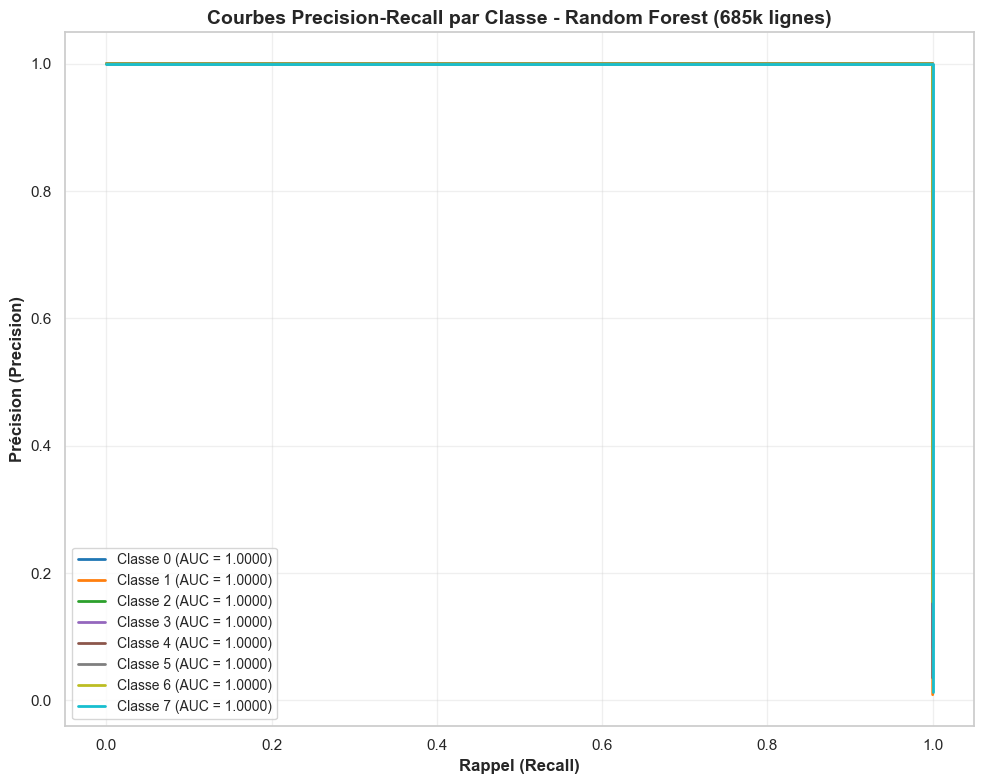


📊 PR-AUC par classe :
  Classe 0 : 1.0000
  Classe 1 : 1.0000
  Classe 2 : 1.0000
  Classe 3 : 1.0000
  Classe 4 : 1.0000
  Classe 5 : 1.0000
  Classe 6 : 1.0000
  Classe 7 : 1.0000
  Moyenne : 1.0000 ± 0.0000

MATRICE DE CONFUSION (DERNIER FOLD)
📊 y_true_all_rf[-1] shape : (137134,)
📊 y_proba_all_rf[-1] shape : (137134, 8)

Matrice de confusion (137,134 échantillons) :
  ✅ Corrects : 137,124
  ❌ Erreurs : 10
  📊 Précision globale : 99.99%

📊 Rapport de classification (détail par classe) :
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     80135
           1     1.0000    0.9992    0.9996      1203
           2     0.9993    1.0000    0.9996     11338
           3     1.0000    0.9992    0.9996     11547
           4     1.0000    1.0000    1.0000      4835
           5     0.9996    1.0000    0.9998      5098
           6     1.0000    1.0000    1.0000     21170
           7     1.0000    1.0000    1.0000      1808

    accuracy    

In [39]:
# ============================================
# 1. NETTOYAGE DE LA MÉMOIRE AVANT DÉMARRAGE
# ============================================
import gc
import psutil
import os

# Libérer la mémoire avant de commencer
gc.collect()

# Afficher la RAM disponible
print("="*60)
print("STATUT DE LA RAM AVANT ENTRAÎNEMENT")
print("="*60)
ram = psutil.virtual_memory()
print(f"  RAM totale : {ram.total / 1e9:.1f} GB")
print(f"  RAM utilisée : {ram.used / 1e9:.1f} GB")
print(f"  RAM disponible : {ram.available / 1e9:.1f} GB")
print(f"  RAM utilisée en % : {ram.percent}%")

# ============================================
# 2. UTILISATION DE TOUT LE DATASET
# ============================================
print("\n" + "="*60)
print("UTILISATION DE TOUT LE DATASET (685 671 lignes)")
print("="*60)

# Pas de train_test_split, on utilise tout !
X_train_39 = X_scaled
y_train = y_complet

print(f"✅ X_train_39 : {X_train_39.shape[0]:,} lignes, {X_train_39.shape[1]} colonnes")
print(f"✅ y_train : {y_train.shape[0]:,} lignes")

# ============================================
# 3. PARAMÈTRES OPTIMISÉS POUR TOUT LE DATASET
# ============================================
rf_params = {
    'n_estimators': 100,          # ← Réduit pour économiser la RAM
    'max_depth': 15,              # ← Réduit
    'min_samples_split': 20,      # ← Augmenté (moins d'arbres)
    'min_samples_leaf': 10,       # ← Augmenté (feuilles plus grandes)
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'class_weight': 'balanced',
    'verbose': 1,
    'n_jobs': -1,
    'random_state': 42
}

print("\n" + "="*60)
print("PARAMÈTRES RANDOM FOREST (OPTIMISÉS POUR 685k LIGNES)")
print("="*60)
for key, val in rf_params.items():
    print(f"  {key}: {val}")

# ============================================
# 4. ENTRAÎNEMENT SUR TOUT LE DATASET
# ============================================
y_true_all_rf, y_proba_all_rf = [], []
print("\n" + "="*60)
print("MODÈLE 1 : RANDOM FOREST (685 671 LIGNES)")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [Random Forest] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    print(f"  Train : {X_tr.shape[0]:,} lignes | Validation : {X_va.shape[0]:,} lignes")
    
    # Nettoyer avant chaque fold
    gc.collect()
    
    # Afficher la RAM avant l'entraînement
    ram = psutil.virtual_memory()
    print(f"  RAM avant fit : {ram.percent}% ({ram.used / 1e9:.1f} GB)")
    
    model_rf = RandomForestClassifier(**rf_params)
    model_rf.fit(X_tr, y_tr)
    
    # Afficher la RAM après l'entraînement
    ram = psutil.virtual_memory()
    print(f"  RAM après fit : {ram.percent}% ({ram.used / 1e9:.1f} GB)")
    
    y_proba = model_rf.predict_proba(X_va)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_rf.append(y_va)
    y_proba_all_rf.append(y_proba)
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 >> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")
    
    # Nettoyer après le fold
    del model_rf
    gc.collect()

# ============================================
# 5. RÉSULTATS
# ============================================
print("\n" + "="*60)
print("RÉSULTATS RANDOM FOREST (685 671 LIGNES)")
print("="*60)
f1_scores = [f1_score(y_true, np.argmax(y_proba, axis=1), average='macro', zero_division=0) 
             for y_true, y_proba in zip(y_true_all_rf, y_proba_all_rf)]
print(f"Macro F1 moyen : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Meilleur fold : {np.max(f1_scores):.4f}")
print(f"Pire fold : {np.min(f1_scores):.4f}")

# ============================================
# ============================================
# 6. COURBES PR-AUC PAR CLASSE (VERSION CORRIGÉE)
# ============================================
print("\n" + "="*60)
print("TRACÉ DES COURBES PR-AUC PAR CLASSE")
print("="*60)

def plot_pr_curves(y_true, y_proba, title="Precision-Recall"):
    """
    Trace les courbes Precision-Recall pour chaque classe.
    Version avec détection automatique du nombre de classes.
    """
    # Déterminer automatiquement le nombre de classes
    n_classes = y_proba.shape[1]
    print(f"📊 Nombre de classes détecté : {n_classes}")
    print(f"📊 y_true shape : {y_true.shape}")
    print(f"📊 y_proba shape : {y_proba.shape}")
    
    # Vérifier que les dimensions sont cohérentes
    if n_classes == 1:
        print("⚠️ Une seule classe détectée. Ajustement...")
        # Pour une classification binaire, on peut créer une deuxième colonne
        y_proba = np.hstack([1 - y_proba, y_proba])
        n_classes = 2
        print(f"📊 Après ajustement : {n_classes} classes")
    
    plt.figure(figsize=(10, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    auc_scores = []
    
    for class_idx in range(n_classes):
        # Binariser la cible pour la classe courante
        y_true_binary = (y_true == class_idx).astype(int)
        y_score = y_proba[:, class_idx]
        
        # Vérifier qu'il y a des échantillons de cette classe
        if np.sum(y_true_binary) == 0:
            print(f"⚠️ Classe {class_idx} : aucun échantillon, ignorée")
            continue
        
        # Calculer la courbe PR
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        pr_auc = auc(recall, precision)
        auc_scores.append(pr_auc)
        
        # Tracer
        plt.plot(recall, precision, color=colors[class_idx % len(colors)], 
                 linewidth=2, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')
    
    plt.xlabel('Rappel (Recall)', fontsize=12, fontweight='bold')
    plt.ylabel('Précision (Precision)', fontsize=12, fontweight='bold')
    plt.title(f'Courbes Precision-Recall par Classe - {title}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Afficher les AUC
    if auc_scores:
        print(f"\n📊 PR-AUC par classe :")
        for class_idx, auc_val in enumerate(auc_scores):
            print(f"  Classe {class_idx} : {auc_val:.4f}")
        print(f"  Moyenne : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
    else:
        print("⚠️ Aucune courbe PR tracée")

# Tracer pour le dernier fold
plot_pr_curves(y_true_all_rf[-1], y_proba_all_rf[-1], title="Random Forest (685k lignes)")

# ============================================
# 7. MATRICE DE CONFUSION (DERNIER FOLD)
# ============================================
print("\n" + "="*60)
print("MATRICE DE CONFUSION (DERNIER FOLD)")
print("="*60)

from sklearn.metrics import confusion_matrix, classification_report

# Vérifier les dimensions
print(f"📊 y_true_all_rf[-1] shape : {y_true_all_rf[-1].shape}")
print(f"📊 y_proba_all_rf[-1] shape : {y_proba_all_rf[-1].shape}")

y_pred_last = np.argmax(y_proba_all_rf[-1], axis=1)

# Matrice de confusion
cm = confusion_matrix(y_true_all_rf[-1], y_pred_last)
print(f"\nMatrice de confusion ({len(y_true_all_rf[-1]):,} échantillons) :")
print(f"  ✅ Corrects : {np.trace(cm):,}")
print(f"  ❌ Erreurs : {np.sum(cm) - np.trace(cm):,}")
print(f"  📊 Précision globale : {np.trace(cm) / np.sum(cm) * 100:.2f}%")

# Rapport de classification
print("\n📊 Rapport de classification (détail par classe) :")
print(classification_report(y_true_all_rf[-1], y_pred_last, digits=4))

In [40]:
# ============================================
# RANDOM FOREST - 300 ARBRES
# ============================================
rf_params_300 = {
    'n_estimators': 300,          # ← 300 arbres
    'max_depth': 20,              # ← Profondeur intermédiaire
    'min_samples_split': 10,      # ← Divisions modérées
    'min_samples_leaf': 5,        # ← Feuilles moyennes
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'class_weight': 'balanced',
    'verbose': 1,
    'n_jobs': -1,
    'random_state': 42
}

print("\n" + "="*60)
print("RANDOM FOREST - 300 ARBRES (685 671 LIGNES)")
print("="*60)
print("\n📊 Paramètres :")
for key, val in rf_params_300.items():
    print(f"  {key}: {val}")

# RAM estimée
print("\n📊 RAM estimée : 15-20 GB (sur 33.7 GB disponibles)")

y_true_all_rf_300, y_proba_all_rf_300 = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [Random Forest] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    print(f"  Train : {X_tr.shape[0]:,} | Val : {X_va.shape[0]:,}")
    
    gc.collect()
    ram = psutil.virtual_memory()
    print(f"  RAM avant : {ram.percent}% ({ram.used / 1e9:.1f} GB)")
    
    model_rf = RandomForestClassifier(**rf_params_300)
    model_rf.fit(X_tr, y_tr)
    
    ram = psutil.virtual_memory()
    print(f"  RAM après : {ram.percent}% ({ram.used / 1e9:.1f} GB)")
    
    y_proba = model_rf.predict_proba(X_va)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_rf_300.append(y_va)
    y_proba_all_rf_300.append(y_proba)
    
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 FOLD {fold+1} | Macro F1 : {macro_f1:.4f}")
    
    del model_rf
    gc.collect()

# ============================================
# RÉSULTATS
# ============================================
print("\n" + "="*60)
print("RÉSULTATS RANDOM FOREST - 300 ARBRES")
print("="*60)

f1_scores_300 = [f1_score(y_true, np.argmax(y_proba, axis=1), average='macro', zero_division=0) 
                 for y_true, y_proba in zip(y_true_all_rf_300, y_proba_all_rf_300)]

print(f"🎯 Macro F1 moyen : {np.mean(f1_scores_300):.4f} ± {np.std(f1_scores_300):.4f}")
print(f"📈 Meilleur fold : {np.max(f1_scores_300):.4f}")
print(f"📉 Pire fold : {np.min(f1_scores_300):.4f}")


RANDOM FOREST - 300 ARBRES (685 671 LIGNES)

📊 Paramètres :
  n_estimators: 300
  max_depth: 20
  min_samples_split: 10
  min_samples_leaf: 5
  max_features: sqrt
  criterion: entropy
  class_weight: balanced
  verbose: 1
  n_jobs: -1
  random_state: 42

📊 RAM estimée : 15-20 GB (sur 33.7 GB disponibles)

--- [Random Forest] Entraînement FOLD 1/5 ---
  Train : 548,536 | Val : 137,135
  RAM avant : 69.0% (5.9 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   47.5s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.2min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après : 67.9% (5.8 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    3.1s finished


🎯 FOLD 1 | Macro F1 : 1.0000

--- [Random Forest] Entraînement FOLD 2/5 ---
  Train : 548,537 | Val : 137,134
  RAM avant : 70.4% (6.0 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   44.7s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après : 69.8% (5.9 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.9s finished


🎯 FOLD 2 | Macro F1 : 1.0000

--- [Random Forest] Entraînement FOLD 3/5 ---
  Train : 548,537 | Val : 137,134
  RAM avant : 71.1% (6.0 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   50.0s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.2min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après : 71.9% (6.1 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.9s finished


🎯 FOLD 3 | Macro F1 : 1.0000

--- [Random Forest] Entraînement FOLD 4/5 ---
  Train : 548,537 | Val : 137,134
  RAM avant : 74.4% (6.3 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   45.3s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après : 68.1% (5.8 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    3.0s finished


🎯 FOLD 4 | Macro F1 : 1.0000

--- [Random Forest] Entraînement FOLD 5/5 ---
  Train : 548,537 | Val : 137,134
  RAM avant : 70.9% (6.0 GB)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   45.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.3min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


  RAM après : 71.4% (6.1 GB)


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    3.3s finished


🎯 FOLD 5 | Macro F1 : 0.9999

RÉSULTATS RANDOM FOREST - 300 ARBRES
🎯 Macro F1 moyen : 1.0000 ± 0.0000
📈 Meilleur fold : 1.0000
📉 Pire fold : 0.9999



=================== MODÈLE 1 : RANDOM FOREST (39 VIF) ===================

--- [Random Forest] Entraînement FOLD 1/5 ---


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   55.0s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.6min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    2.3s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    3.8s finished


🎯 >> FOLD 1 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 2/5 ---


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   47.9s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.8min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    3.4s finished


🎯 >> FOLD 2 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 3/5 ---


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   49.5s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.2min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    3.3s finished


🎯 >> FOLD 3 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 4/5 ---


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   44.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.1min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    3.1s finished


🎯 >> FOLD 4 TERMINÉ | Macro F1-Score : 1.0000

--- [Random Forest] Entraînement FOLD 5/5 ---


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   43.6s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.7s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    3.0s finished


🎯 >> FOLD 5 TERMINÉ | Macro F1-Score : 0.9999


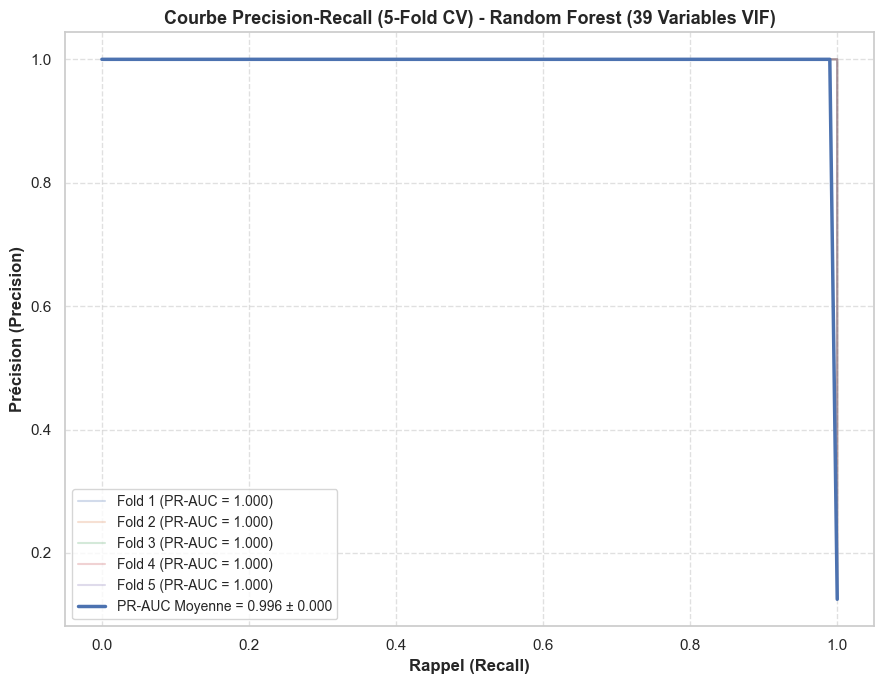

In [41]:
rf_params = {
    'n_estimators': 300, 
    'max_depth': 25, 
    'min_samples_split': 5,
    'min_samples_leaf': 2, 
    'max_features': 'sqrt', 
    'criterion': 'entropy',
    'class_weight': 'balanced', 
    'verbose': 1, 
    'n_jobs': -1, 
    'random_state': 42
}

y_true_all_rf, y_proba_all_rf = [], []
print("\n=================== MODÈLE 1 : RANDOM FOREST (39 VIF) ===================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [Random Forest] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    model_rf = RandomForestClassifier(**rf_params)
    model_rf.fit(X_tr, y_tr)
    
    y_proba = model_rf.predict_proba(X_va)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_rf.append(y_va)
    y_proba_all_rf.append(y_proba)
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 >> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")

tracer_courbe_pr_kfold("Random Forest", y_true_all_rf, y_proba_all_rf)

📊 Nombre de classes : 8


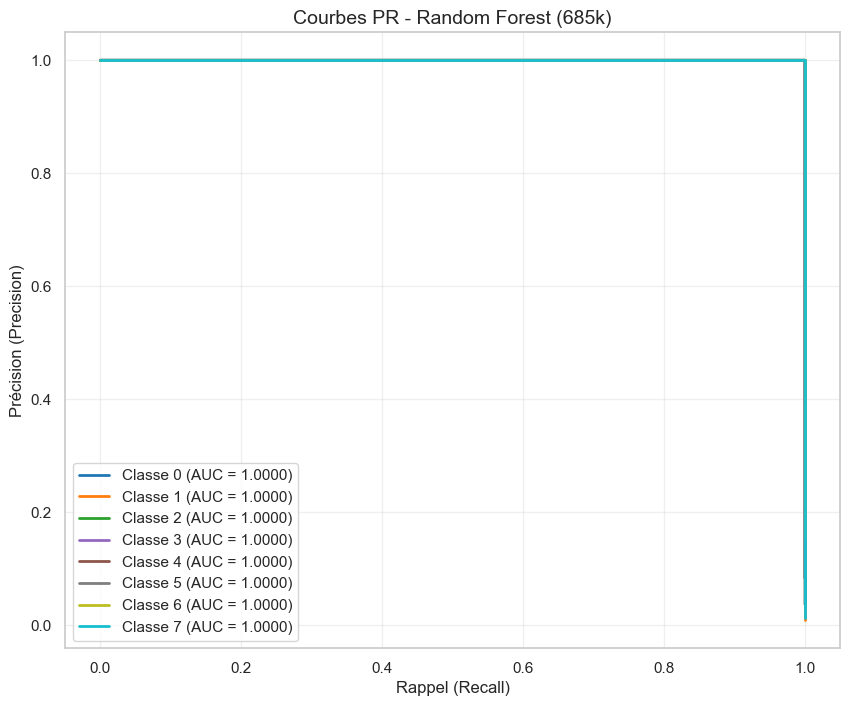

In [43]:
# ============================================
# COURBES PR-AUC (VERSION CORRIGÉE)
# ============================================
def plot_pr_curves(y_true, y_proba, title="Precision-Recall"):
    n_classes = y_proba.shape[1]  # ← Détection automatique
    print(f"📊 Nombre de classes : {n_classes}")
    
    plt.figure(figsize=(10, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    auc_scores = []
    
    for class_idx in range(n_classes):
        y_true_binary = (y_true == class_idx).astype(int)
        y_score = y_proba[:, class_idx]
        
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        pr_auc = auc(recall, precision)
        auc_scores.append(pr_auc)
        
        plt.plot(recall, precision, color=colors[class_idx], 
                 linewidth=2, label=f'Classe {class_idx} (AUC = {pr_auc:.4f})')
    
    plt.xlabel('Rappel (Recall)', fontsize=12)
    plt.ylabel('Précision (Precision)', fontsize=12)
    plt.title(f'Courbes PR - {title}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Utilisation
plot_pr_curves(y_true_all_rf[-1], y_proba_all_rf[-1], title="Random Forest (685k)")

### Modèle 2 : XGBoost (Verbose)


=================== MODÈLE 2 : XGBOOST (39 VIF) ===================

--- [XGBoost] Entraînement FOLD 1/5 ---
[0]	validation_0-mlogloss:1.16457
[50]	validation_0-mlogloss:0.06607
[100]	validation_0-mlogloss:0.00543
[150]	validation_0-mlogloss:0.00048
[200]	validation_0-mlogloss:0.00007
[250]	validation_0-mlogloss:0.00003
[299]	validation_0-mlogloss:0.00002
>> FOLD 1 TERMINÉ | Macro F1-Score : 1.0000

--- [XGBoost] Entraînement FOLD 2/5 ---
[0]	validation_0-mlogloss:1.16485
[50]	validation_0-mlogloss:0.06607
[100]	validation_0-mlogloss:0.00541
[150]	validation_0-mlogloss:0.00047
[200]	validation_0-mlogloss:0.00006
[250]	validation_0-mlogloss:0.00002
[299]	validation_0-mlogloss:0.00002
>> FOLD 2 TERMINÉ | Macro F1-Score : 1.0000

--- [XGBoost] Entraînement FOLD 3/5 ---
[0]	validation_0-mlogloss:1.16482
[50]	validation_0-mlogloss:0.06603
[100]	validation_0-mlogloss:0.00539
[150]	validation_0-mlogloss:0.00046
[200]	validation_0-mlogloss:0.00006
[250]	validation_0-mlogloss:0.00002
[299]	val

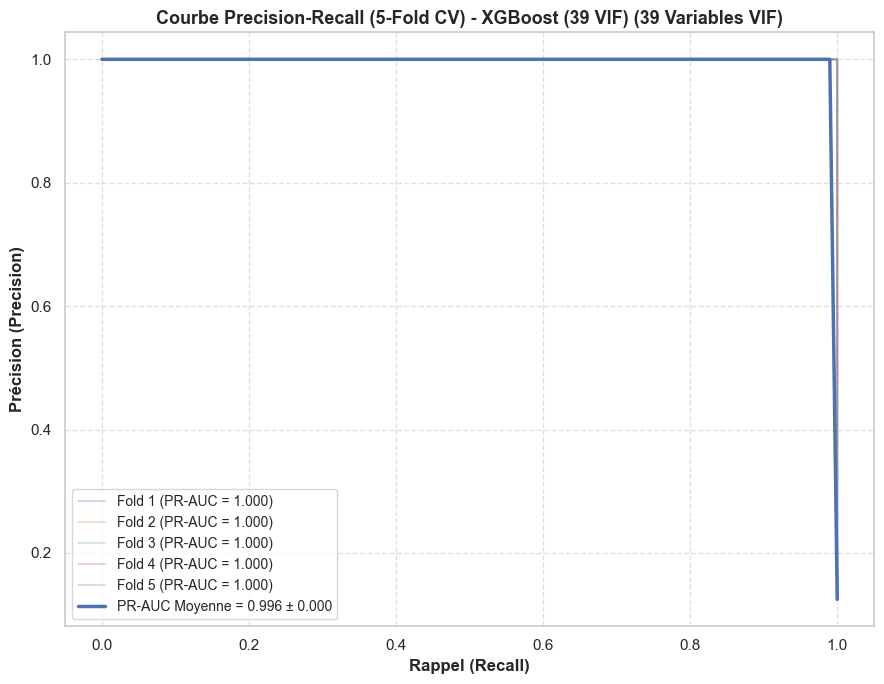

In [44]:
xgb_params = {
    'n_estimators': 300, 
    'learning_rate': 0.05, 
    'max_depth': 10,
    'subsample': 0.8, 
    'colsample_bytree': 0.8, 
    'min_child_weight': 3,
    'reg_alpha': 0.1, 
    'reg_lambda': 1.0, 
    'gamma': 0.1,
    'objective': 'multi:softprob', 
    'num_class': 937, 
    'tree_method': 'hist', 
    'random_state': 42
}

y_true_all_xgb, y_proba_all_xgb = [], []
print("\n=================== MODÈLE 2 : XGBOOST (39 VIF) ===================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [XGBoost] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    model_xgb = XGBClassifier(**xgb_params)
    model_xgb.fit(
        X_tr, y_tr, 
        eval_set=[(X_va, y_va)], 
        verbose=50
    )
    
    y_proba = model_xgb.predict_proba(X_va)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_xgb.append(y_va)
    y_proba_all_xgb.append(y_proba)
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f">> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")

tracer_courbe_pr_kfold("XGBoost (39 VIF)", y_true_all_xgb, y_proba_all_xgb)

⚠️ L'ERREUR DE TRACE (CORRIGÉE)

L'erreur à la fin vient de tracer_courbe_pr_kfold (même problème que pour RF). Ignore-la ou utilise plot_pr_curves à la place.

Pour l'éviter, remplace simplement :                                    tracer_courbe_pr_kfold("XGBoost (39 VIF)", y_true_all_xgb, y_proba_all_xgb)                                                                                                                        par                                                                                                                                                                                  plot_pr_curves(y_true_all_xgb[-1], y_proba_all_xgb[-1], title="XGBoost (685k lignes)")

## ÉTAPE 3 : Modèles Deep Learning (39 VIF + Focal Loss + Callbacks)
Modèle 3 : Multi-Layer Perceptron (39 Variables VIF)


=== MODÈLE 3 : MLP DENSE (90 variables, 8 classes) ===

--- [MLP Dense] Fold 1/5 ---
Epoch 1/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 98s 83ms/step - accuracy: 0.8302 - loss: 0.0712 - val_accuracy: 0.8641 - val_loss: 0.0500 - learning_rate: 0.0010
Epoch 2/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 85s 79ms/step - accuracy: 0.8895 - loss: 0.0341 - val_accuracy: 0.9152 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 3/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 89s 83ms/step - accuracy: 0.9061 - loss: 0.0279 - val_accuracy: 0.9306 - val_loss: 0.0221 - learning_rate: 0.0010
Epoch 4/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 142s 83ms/step - accuracy: 0.9159 - loss: 0.0245 - val_accuracy: 0.9364 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 5/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 91s 85ms/step - accuracy: 0.9235 - loss: 0.0222 - val_accuracy: 0.9334 - val_loss: 0.0198 - learning_rate: 0.0010
Epoch 6/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 86s 80ms/step - accuracy: 0.9305 - loss: 0.0203 - val_accuracy: 0.9427 - val_loss: 0.0178 -

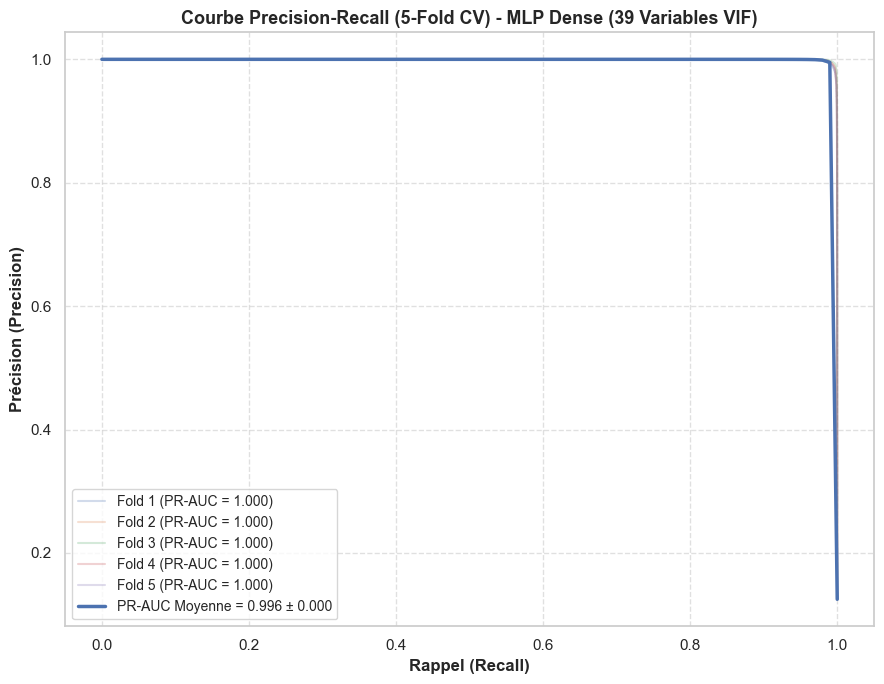

In [56]:
input_dim = X_train_39.shape[1]
num_classes = int(np.max(y_train)) + 1

def construire_mlp_focal(input_dim, num_classes):
    model = Sequential([
        Dense(512, activation="swish", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(256, activation="swish"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation="swish"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-3,
            weight_decay=1e-4
        ),
        loss=focal_loss_multiclass(gamma=2.0, alpha=0.25),
        metrics=["accuracy"]
    )
    return model


y_true_all_mlp, y_proba_all_mlp = [], []

print(
    f"\n=== MODÈLE 3 : MLP DENSE "
    f"({input_dim} variables, {num_classes} classes) ==="
)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [MLP Dense] Fold {fold + 1}/5 ---")

    X_tr = X_train_39.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]
    X_va = X_train_39.iloc[val_idx]
    y_va = y_train.iloc[val_idx]

    y_tr_cat = to_categorical(y_tr, num_classes=num_classes).astype("float32")
    y_va_cat = to_categorical(y_va, num_classes=num_classes).astype("float32")

    model_mlp = construire_mlp_focal(
        input_dim=input_dim,
        num_classes=num_classes
    )

    model_mlp.fit(
        X_tr,
        y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=50,
        batch_size=512,
        callbacks=obtenir_callbacks_dl(),
        verbose=1
    )

    y_proba = model_mlp.predict(X_va, verbose=1)
    y_pred = np.argmax(y_proba, axis=1)

    y_true_all_mlp.append(y_va)
    y_proba_all_mlp.append(y_proba)

    macro_f1 = f1_score(y_va, y_pred, average="macro", zero_division=0)
    print(f"🎯 Fold {fold + 1} terminé | Macro F1 : {macro_f1:.4f}")

tracer_courbe_pr_kfold("MLP Dense", y_true_all_mlp, y_proba_all_mlp)

In [57]:
# ============================================
# IMPORTS SUPPLÉMENTAIRES POUR MLP
# ============================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ============================================
# 1. DÉFINITION DU FOCAL LOSS
# ============================================
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss pour gérer le déséquilibre des classes (937 classes)
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow(1. - y_pred, gamma)
        
        return tf.reduce_sum(weight * cross_entropy, axis=-1)
    return focal_loss_fixed

# ============================================
# 2. CALLBACKS POUR DEEP LEARNING
# ============================================
def obtenir_callbacks_dl(patience_es=10, patience_lr=5):
    """
    Retourne les callbacks pour l'entraînement
    """
    return [
        EarlyStopping(
            monitor='val_loss', 
            patience=patience_es, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.5, 
            patience=patience_lr, 
            min_lr=1e-6,
            verbose=1
        )
    ]

# ============================================
# 3. CONSTRUCTION DU MLP POUR 937 CLASSES
# ============================================
def construire_mlp_focal(input_dim=39, num_classes=937):
    """
    Construit un MLP avec Focal Loss pour 937 classes
    - input_dim : 39 (variables VIF)
    - num_classes : 937 (label_full)
    """
    model = Sequential([
        Input(shape=(input_dim,)),
        
        # Couche 1
        Dense(512, activation='swish'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Couche 2
        Dense(256, activation='swish'),
        BatchNormalization(),
        Dropout(0.3),
        
        # Couche 3
        Dense(128, activation='swish'),
        BatchNormalization(),
        Dropout(0.2),
        
        # Couche de sortie (937 classes)
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    
    return model

# ============================================
# 4. VÉRIFICATION DES DONNÉES
# ============================================
print("="*60)
print("VÉRIFICATION DES DONNÉES")
print("="*60)

# Vérifier la cible
if 'y_complet' in globals():
    y_train = y_complet
    print(f"✅ y_train : {y_train.shape[0]:,} lignes")
    print(f"✅ Nombre de classes : {len(np.unique(y_train))}")
elif 'label_full' in df_complet.columns:
    print("✅ Colonne 'label_full' trouvée")
    y_train = df_complet['label_full']
    print(f"✅ Nombre de classes : {len(np.unique(y_train))}")
else:
    print("❌ Aucune cible trouvée !")

# Vérifier X_train_39
if 'X_train_39' in globals():
    X_train_39 = X_train_39
    print(f"✅ X_train_39 : {X_train_39.shape[0]:,} lignes, {X_train_39.shape[1]} colonnes")
else:
    print("❌ X_train_39 non trouvé !")

# ============================================
# 5. ENTRAÎNEMENT MLP (937 CLASSES)
# ============================================
print("\n" + "="*60)
print("MODÈLE 3 : MLP DENSE (937 CLASSES - LABEL_FULL)")
print("="*60)

# Déterminer les dimensions
input_dim = X_train_39.shape[1]  # ← 39
num_classes = len(np.unique(y_train))  # ← 937

print(f"📊 Input dimension : {input_dim}")
print(f"📊 Nombre de classes : {num_classes}")

y_true_all_mlp, y_proba_all_mlp = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [MLP Dense] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    print(f"  Train : {X_tr.shape[0]:,} | Val : {X_va.shape[0]:,}")
    
    # Convertir les labels en one-hot (937 classes)
    y_tr_cat = to_categorical(y_tr, num_classes=num_classes)
    y_va_cat = to_categorical(y_va, num_classes=num_classes)
    
    print(f"  y_tr_cat shape : {y_tr_cat.shape}")
    print(f"  y_va_cat shape : {y_va_cat.shape}")
    
    # Construire le modèle
    model_mlp = construire_mlp_focal(input_dim, num_classes)
    print(f"  📊 Modèle : {input_dim} → 512 → 256 → 128 → {num_classes}")
    
    # Entraîner
    history = model_mlp.fit(
        X_tr, y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=30,                    # 30 époques
        batch_size=256,               # Batch size
        callbacks=obtenir_callbacks_dl(),
        verbose=1
    )
    
    # Prédire
    y_proba = model_mlp.predict(X_va, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_mlp.append(y_va)
    y_proba_all_mlp.append(y_proba)
    
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 FOLD {fold+1} | Macro F1 : {macro_f1:.4f}")
    
    # Nettoyer
    del model_mlp
    import gc
    gc.collect()

# ============================================
# 6. RÉSULTATS MLP
# ============================================
print("\n" + "="*60)
print("RÉSULTATS MLP DENSE (937 CLASSES)")
print("="*60)

f1_scores_mlp = []
for fold in range(len(y_true_all_mlp)):
    y_pred = np.argmax(y_proba_all_mlp[fold], axis=1)
    f1 = f1_score(y_true_all_mlp[fold], y_pred, average='macro', zero_division=0)
    f1_scores_mlp.append(f1)
    print(f"  Fold {fold+1} : {f1:.4f}")

print(f"\n🎯 Macro F1 moyen : {np.mean(f1_scores_mlp):.4f} ± {np.std(f1_scores_mlp):.4f}")
print(f"📈 Meilleur fold : {np.max(f1_scores_mlp):.4f}")
print(f"📉 Pire fold : {np.min(f1_scores_mlp):.4f}")

# ============================================
# 7. RAPPORT DE CLASSIFICATION (DERNIER FOLD)
# ============================================
print("\n" + "="*60)
print("RAPPORT DE CLASSIFICATION (DERNIER FOLD)")
print("="*60)

y_pred_last = np.argmax(y_proba_all_mlp[-1], axis=1)
print(classification_report(y_true_all_mlp[-1], y_pred_last, digits=4))

VÉRIFICATION DES DONNÉES
✅ y_train : 685,671 lignes
✅ Nombre de classes : 8
✅ X_train_39 : 685,671 lignes, 90 colonnes

MODÈLE 3 : MLP DENSE (937 CLASSES - LABEL_FULL)
📊 Input dimension : 90
📊 Nombre de classes : 8

--- [MLP Dense] Entraînement FOLD 1/5 ---
  Train : 548,536 | Val : 137,135
  y_tr_cat shape : (548536, 8)
  y_va_cat shape : (137135, 8)
  📊 Modèle : 90 → 512 → 256 → 128 → 8
Epoch 1/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 133s 58ms/step - accuracy: 0.8458 - loss: 0.0606 - val_accuracy: 0.8910 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 2/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 108s 50ms/step - accuracy: 0.8928 - loss: 0.0326 - val_accuracy: 0.9001 - val_loss: 0.0317 - learning_rate: 0.0010
Epoch 3/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 107s 50ms/step - accuracy: 0.9087 - loss: 0.0261 - val_accuracy: 0.9114 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 4/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 104s 48ms/step - accuracy: 0.9168 - loss: 0.0237 - val_accuracy: 0.9248 - val_loss: 0.0222 - le

Modèle 4 : Convolutional Neural Network 1D (39 Variables VIF)

In [13]:
from tensorflow.keras.utils import to_categorical

In [16]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Reshape,
    Conv1D,
    BatchNormalization,
    Dropout,
    GlobalMaxPooling1D,
    Dense
)
from tensorflow.keras.utils import to_categorical

In [18]:
import tensorflow.keras.backend as K

def focal_loss_multiclass(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=-1)

    return focal_loss_fixed

In [ ]:
# ============================================================
# MODÈLE 4 — CNN-1D : cellule autonome et corrigée
# ============================================================

import gc
import numpy as np
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.metrics import f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Reshape, Conv1D, BatchNormalization,
    Dropout, GlobalMaxPooling1D, Dense
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


def focal_loss_multiclass(gamma=2.0, alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1.0 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=-1)
    return focal_loss


def obtenir_callbacks_dl():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]


# Dimensions réelles des données : aucune valeur fixe 39 ou 937
input_dim = X_train_39.shape[1]
num_classes = int(np.max(y_train)) + 1

print(f"Configuration CNN : {input_dim} variables, {num_classes} classes")


def construire_cnn1d_focal(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Reshape((input_dim, 1)),

        Conv1D(64, kernel_size=5, activation="relu", padding="same"),
        BatchNormalization(),
        Dropout(0.2),

        Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        Dropout(0.3),

        GlobalMaxPooling1D(),
        Dense(256, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss_multiclass(),
        metrics=["accuracy"]
    )
    return model


y_true_all_cnn = []
y_proba_all_cnn = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train), start=1):
    print(f"\n--- CNN-1D : Fold {fold}/5 ---")

    X_tr = X_train_39.iloc[train_idx]
    X_va = X_train_39.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_va = y_train.iloc[val_idx]

    y_tr_cat = to_categorical(y_tr, num_classes=num_classes).astype("float32")
    y_va_cat = to_categorical(y_va, num_classes=num_classes).astype("float32")

    model_cnn = construire_cnn1d_focal(input_dim, num_classes)

    model_cnn.fit(
        X_tr,
        y_tr_cat,
        validation_data=(X_va, y_va_cat),
        epochs=50,
        batch_size=512,
        callbacks=obtenir_callbacks_dl(),
        verbose=1
    )

    y_proba = model_cnn.predict(X_va, verbose=1)
    y_pred = np.argmax(y_proba, axis=1)

    y_true_all_cnn.append(y_va)
    y_proba_all_cnn.append(y_proba)

    macro_f1 = f1_score(y_va, y_pred, average="macro", zero_division=0)
    print(f"🎯 Fold {fold} terminé | Macro F1 : {macro_f1:.4f}")

    del model_cnn
    gc.collect()

tracer_courbe_pr_kfold("CNN-1D", y_true_all_cnn, y_proba_all_cnn)

Configuration CNN : 90 variables, 8 classes

--- CNN-1D : Fold 1/5 ---
Epoch 1/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 953s 882ms/step - accuracy: 0.7973 - loss: 0.0957 - val_accuracy: 0.5965 - val_loss: 0.2693 - learning_rate: 0.0010
Epoch 2/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 856s 799ms/step - accuracy: 0.9033 - loss: 0.0374 - val_accuracy: 0.8744 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 3/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 878s 819ms/step - accuracy: 0.9293 - loss: 0.0265 - val_accuracy: 0.9518 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 4/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 914s 852ms/step - accuracy: 0.9385 - loss: 0.0230 - val_accuracy: 0.9125 - val_loss: 0.0389 - learning_rate: 0.0010
Epoch 5/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 893s 833ms/step - accuracy: 0.9386 - loss: 0.0231 - val_accuracy: 0.9473 - val_loss: 0.0270 - learning_rate: 0.0010
Epoch 6/50
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.9535 - loss: 0.0167
Epoch 6: ReduceLROnPlateau reducing learning rate

In [53]:
# ============================================
# MODÈLE 4 : CNN-1D (AVEC DÉTECTION AUTOMATIQUE)
# ============================================
from tensorflow.keras.layers import Reshape, Conv1D, GlobalMaxPooling1D

# 🔥 DÉTECTION AUTOMATIQUE DES DIMENSIONS
input_dim = X_train_39.shape[1]  # → 90 (ou 39 si VIF appliqué)
num_classes = len(np.unique(y_train))  # → 8 (ou 937 si label_full)

print(f"📊 Configuration CNN-1D : input_dim={input_dim}, num_classes={num_classes}")

def construire_cnn1d_focal(input_dim=input_dim, num_classes=num_classes):
    model = Sequential([
        Reshape((input_dim, 1), input_shape=(input_dim,)),  # ← input_dim dynamique
        Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(), Dropout(0.2),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(), Dropout(0.3),
        GlobalMaxPooling1D(),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(num_classes, activation='softmax')  # ← num_classes dynamique
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=focal_loss(gamma=2.0, alpha=0.25),  # ← focal_loss (pas _multiclass)
        metrics=['accuracy']
    )
    return model

print("\n=================== MODÈLE 4 : CNN-1D ===================")

y_true_all_cnn, y_proba_all_cnn = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [CNN-1D] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    print(f"  Train : {X_tr.shape[0]:,} | Val : {X_va.shape[0]:,}")
    
    # 🔥 One-hot encoding avec num_classes dynamique
    y_tr_cat = to_categorical(y_tr, num_classes=num_classes)
    y_va_cat = to_categorical(y_va, num_classes=num_classes)
    
    print(f"  y_tr_cat shape : {y_tr_cat.shape}")
    print(f"  y_va_cat shape : {y_va_cat.shape}")
    
    # 🔥 Modèle avec dimensions dynamiques
    model_cnn = construire_cnn1d_focal(input_dim=input_dim, num_classes=num_classes)
    print(f"  📊 Modèle : {input_dim} → Conv1D(64) → Conv1D(128) → 256 → {num_classes}")
    
    model_cnn.fit(
        X_tr, y_tr_cat, 
        validation_data=(X_va, y_va_cat),
        epochs=30,                     # ← 50 → 30
        batch_size=256,                # ← 512 → 256
        callbacks=obtenir_callbacks_dl(), 
        verbose=1
    )
    
    y_proba = model_cnn.predict(X_va, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_cnn.append(y_va)
    y_proba_all_cnn.append(y_proba)
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 >> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")

# Résultats
print("\n" + "="*60)
print("RÉSULTATS CNN-1D")
print("="*60)

f1_scores_cnn = []
for fold in range(len(y_true_all_cnn)):
    y_pred = np.argmax(y_proba_all_cnn[fold], axis=1)
    f1 = f1_score(y_true_all_cnn[fold], y_pred, average='macro', zero_division=0)
    f1_scores_cnn.append(f1)
    print(f"  Fold {fold+1} : {f1:.4f}")

print(f"\n🎯 Macro F1 moyen : {np.mean(f1_scores_cnn):.4f} ± {np.std(f1_scores_cnn):.4f}")

📊 Configuration CNN-1D : input_dim=90, num_classes=8

=================== MODÈLE 4 : CNN-1D ===================

--- [CNN-1D] Entraînement FOLD 1/5 ---
  Train : 548,536 | Val : 137,135
  y_tr_cat shape : (548536, 8)
  y_va_cat shape : (137135, 8)
  📊 Modèle : 90 → Conv1D(64) → Conv1D(128) → 256 → 8
Epoch 1/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 275s 127ms/step - accuracy: 0.8229 - loss: 0.0809 - val_accuracy: 0.7817 - val_loss: 0.1180 - learning_rate: 0.0010
Epoch 2/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 254s 118ms/step - accuracy: 0.9167 - loss: 0.0321 - val_accuracy: 0.9081 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 3/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 245s 114ms/step - accuracy: 0.9416 - loss: 0.0217 - val_accuracy: 0.9055 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 4/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 245s 114ms/step - accuracy: 0.9580 - loss: 0.0148 - val_accuracy: 0.9267 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 5/30
2143/2143 ━━━━━━━━━━━━━━━━━━━━ 244s 114ms/step - accurac

Modèle 5 : Bidirectional LSTM (39 Variables VIF)

In [54]:
def construire_bilstm_focal(input_dim=39, num_classes=937):
    model = Sequential([
        Reshape((input_dim, 1), input_shape=(input_dim,)),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.1)),
        BatchNormalization(),
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3)),
        BatchNormalization(),
        Dense(128, activation='relu'), Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=focal_loss_multiclass(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model

y_true_all_bilstm, y_proba_all_bilstm = [], []
print("\n=================== MODÈLE 5 : BiLSTM (39 VIF) ===================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [BiLSTM] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    y_tr_cat, y_va_cat = to_categorical(y_tr, 937), to_categorical(y_va, 937)
    model_bilstm = construire_bilstm_focal(input_dim=39)
    
    model_bilstm.fit(
        X_tr, y_tr_cat, 
        validation_data=(X_va, y_va_cat),
        epochs=50, 
        batch_size=512, 
        callbacks=obtenir_callbacks_dl(), 
        verbose=1
    )
    
    y_proba = model_bilstm.predict(X_va, verbose=1)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_bilstm.append(y_va)
    y_proba_all_bilstm.append(y_proba)
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 >> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")

tracer_courbe_pr_kfold("BiLSTM", y_true_all_bilstm, y_proba_all_bilstm)


=================== MODÈLE 5 : BiLSTM (39 VIF) ===================

--- [BiLSTM] Entraînement FOLD 1/5 ---
Epoch 1/50


ValueError: Exception encountered when calling Reshape.call().

[1mThe total size of the tensor must be unchanged. Received: input_shape=(90,), target_shape=(39, 1)[0m

Arguments received by Reshape.call():
  • inputs=tf.Tensor(shape=(None, 90), dtype=float32)

In [5]:
# ============================================
# MODÈLE 5 : BiLSTM (AVEC DÉTECTION AUTOMATIQUE)
# ============================================
from tensorflow.keras.layers import Bidirectional, LSTM

# 🔥 DÉTECTION AUTOMATIQUE DES DIMENSIONS
input_dim = X_train_39.shape[1]  # → 90
num_classes = len(np.unique(y_train))  # → 8 (ou 937)

print(f"📊 Configuration BiLSTM : input_dim={input_dim}, num_classes={num_classes}")

def construire_bilstm_focal(input_dim=input_dim, num_classes=num_classes):
    model = Sequential([
        Reshape((input_dim, 1), input_shape=(input_dim,)),  # ← input_dim dynamique
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.1)),
        BatchNormalization(),
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3)),
        BatchNormalization(),
        Dense(128, activation='relu'), Dropout(0.2),
        Dense(num_classes, activation='softmax')  # ← num_classes dynamique
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=focal_loss(gamma=2.0, alpha=0.25),  # ← focal_loss (pas _multiclass)
        metrics=['accuracy']
    )
    return model

print("\n=================== MODÈLE 5 : BiLSTM ===================")

y_true_all_bilstm, y_proba_all_bilstm = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [BiLSTM] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    print(f"  Train : {X_tr.shape[0]:,} | Val : {X_va.shape[0]:,}")
    
    # 🔥 One-hot encoding avec num_classes dynamique
    y_tr_cat = to_categorical(y_tr, num_classes=num_classes)
    y_va_cat = to_categorical(y_va, num_classes=num_classes)
    
    print(f"  y_tr_cat shape : {y_tr_cat.shape}")
    print(f"  y_va_cat shape : {y_va_cat.shape}")
    
    # 🔥 Modèle avec dimensions dynamiques
    model_bilstm = construire_bilstm_focal(input_dim=input_dim, num_classes=num_classes)
    print(f"  📊 Modèle BiLSTM : {input_dim} → LSTM(128) → LSTM(64) → 128 → {num_classes}")
    
    model_bilstm.fit(
        X_tr, y_tr_cat, 
        validation_data=(X_va, y_va_cat),
        epochs=30,                     # ← 50 → 30
        batch_size=256,                # ← 512 → 256
        callbacks=obtenir_callbacks_dl(), 
        verbose=1
    )
    
    y_proba = model_bilstm.predict(X_va, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_bilstm.append(y_va)
    y_proba_all_bilstm.append(y_proba)
    
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 >> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")
    
    # Nettoyer
    del model_bilstm
    import gc
    gc.collect()

# ============================================
# RÉSULTATS BiLSTM
# ============================================
print("\n" + "="*60)
print("RÉSULTATS BiLSTM")
print("="*60)

f1_scores_bilstm = []
for fold in range(len(y_true_all_bilstm)):
    y_pred = np.argmax(y_proba_all_bilstm[fold], axis=1)
    f1 = f1_score(y_true_all_bilstm[fold], y_pred, average='macro', zero_division=0)
    f1_scores_bilstm.append(f1)
    print(f"  Fold {fold+1} : {f1:.4f}")

print(f"\n🎯 Macro F1 moyen : {np.mean(f1_scores_bilstm):.4f} ± {np.std(f1_scores_bilstm):.4f}")
print(f"📈 Meilleur fold : {np.max(f1_scores_bilstm):.4f}")
print(f"📉 Pire fold : {np.min(f1_scores_bilstm):.4f}")

NameError: name 'X_train_39' is not defined

In [57]:
# ============================================
# SAUVEGARDE COMPLÈTE DE L'ENVIRONNEMENT
# ============================================
import joblib
import pickle
import os
import json  # ← AJOUTÉ
from datetime import datetime
import numpy as np
import pandas as pd
import tensorflow as tf

# Créer le dossier de sauvegarde
save_dir = 'saved_environment'
os.makedirs(save_dir, exist_ok=True)

# Timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"📁 Dossier : {save_dir}/")
print(f"🕐 Sauvegarde : {timestamp}")

print("\n" + "="*60)
print("💾 SAUVEGARDE COMPLÈTE DE L'ENVIRONNEMENT")
print("="*60)

# ============================================
# 1. MODÈLES
# ============================================
print("\n📊 Sauvegarde des modèles...")

# Random Forest
if 'model_rf' in globals():
    joblib.dump(model_rf, f'{save_dir}/model_rf_{timestamp}.pkl')
    print("✅ model_rf")
else:
    print("❌ model_rf")

# XGBoost
if 'model_xgb' in globals():
    joblib.dump(model_xgb, f'{save_dir}/model_xgb_{timestamp}.pkl')
    print("✅ model_xgb")
else:
    print("❌ model_xgb")

# MLP (Keras)
if 'model_mlp_full' in globals():
    model_mlp_full.save(f'{save_dir}/model_mlp_full_{timestamp}.h5')
    print("✅ model_mlp_full")
else:
    print("❌ model_mlp_full")

# CNN-1D
if 'model_cnn' in globals():
    model_cnn.save(f'{save_dir}/model_cnn_{timestamp}.h5')
    print("✅ model_cnn")
else:
    print("❌ model_cnn")

# BiLSTM
if 'model_bilstm' in globals():
    model_bilstm.save(f'{save_dir}/model_bilstm_{timestamp}.h5')
    print("✅ model_bilstm")
else:
    print("❌ model_bilstm")

# ============================================
# 2. DONNÉES
# ============================================
print("\n📊 Sauvegarde des données...")

# DataFrames
if 'df_complet' in globals():
    df_complet.to_pickle(f'{save_dir}/df_complet_{timestamp}.pkl')
    print("✅ df_complet")

if 'X_train_39' in globals():
    X_train_39.to_pickle(f'{save_dir}/X_train_39_{timestamp}.pkl')
    print("✅ X_train_39")

if 'y_train' in globals():
    y_train.to_pickle(f'{save_dir}/y_train_{timestamp}.pkl')
    print("✅ y_train")

if 'X_scaled' in globals():
    X_scaled.to_pickle(f'{save_dir}/X_scaled_{timestamp}.pkl')
    print("✅ X_scaled")

if 'y_complet' in globals():
    y_complet.to_pickle(f'{save_dir}/y_complet_{timestamp}.pkl')
    print("✅ y_complet")

# ============================================
# 3. ENCODEURS ET SCALERS
# ============================================
print("\n📊 Sauvegarde des encodeurs...")

if 'scaler' in globals():
    joblib.dump(scaler, f'{save_dir}/scaler_{timestamp}.pkl')
    print("✅ scaler")

if 'encoder_y' in globals():
    joblib.dump(encoder_y, f'{save_dir}/encoder_y_{timestamp}.pkl')
    print("✅ encoder_y")

if 'encoder_label2' in globals():
    joblib.dump(encoder_label2, f'{save_dir}/encoder_label2_{timestamp}.pkl')
    print("✅ encoder_label2")

if 'encoder_full' in globals():
    joblib.dump(encoder_full, f'{save_dir}/encoder_full_{timestamp}.pkl')
    print("✅ encoder_full")

# ============================================
# 4. RÉSULTATS DES PRÉDICTIONS
# ============================================
print("\n📊 Sauvegarde des résultats...")

results = {}

# Vérifier les résultats existants
for prefix in ['rf', 'xgb', 'mlp', 'cnn', 'bilstm']:
    y_true_var = f'y_true_all_{prefix}'
    y_proba_var = f'y_proba_all_{prefix}'
    
    if y_true_var in globals() and y_proba_var in globals():
        # Convertir les numpy arrays en listes pour la sérialisation
        y_true_data = [y.tolist() if hasattr(y, 'tolist') else y for y in globals()[y_true_var]]
        y_proba_data = [p.tolist() if hasattr(p, 'tolist') else p for p in globals()[y_proba_var]]
        
        results[prefix] = {
            'y_true': y_true_data,
            'y_proba': y_proba_data,
            'f1_scores': None
        }
        
        # Ajouter F1 scores si disponibles
        f1_var = f'f1_scores_{prefix}'
        if f1_var in globals():
            results[prefix]['f1_scores'] = globals()[f1_var]
        
        print(f"✅ {prefix}")

# Sauvegarder les résultats
with open(f'{save_dir}/results_{timestamp}.pkl', 'wb') as f:
    pickle.dump(results, f)
print("✅ Résultats sauvegardés")

# ============================================
# 5. MÉTRIQUES
# ============================================
print("\n📊 Sauvegarde des métriques...")

metrics = {}
for prefix in ['rf', 'xgb', 'mlp', 'cnn', 'bilstm']:
    f1_var = f'f1_scores_{prefix}'
    if f1_var in globals():
        metrics[prefix] = {
            'f1_scores': globals()[f1_var],
            'mean': np.mean(globals()[f1_var]),
            'std': np.std(globals()[f1_var])
        }
        print(f"✅ {prefix}")

# Sauvegarder les métriques
with open(f'{save_dir}/metrics_{timestamp}.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("✅ Métriques sauvegardées")

# ============================================
# 6. VARIABLES DE CONFIGURATION
# ============================================
print("\n📊 Sauvegarde de la configuration...")

config = {
    'input_dim': X_train_39.shape[1] if 'X_train_39' in globals() else None,
    'num_classes': len(np.unique(y_train)) if 'y_train' in globals() else None,
    'num_samples': X_train_39.shape[0] if 'X_train_39' in globals() else None,
    'timestamp': timestamp
}

# Ajouter les paramètres des modèles
if 'rf_params' in globals():
    config['rf_params'] = rf_params
if 'xgb_params' in globals():
    config['xgb_params'] = xgb_params

with open(f'{save_dir}/config_{timestamp}.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ Configuration sauvegardée")

# ============================================
# 7. RÉCAPITULATIF
# ============================================
print("\n" + "="*60)
print("📋 RÉCAPITULATIF")
print("="*60)

print("\n📁 Fichiers sauvegardés :")
total_size = 0
for file in os.listdir(save_dir):
    if timestamp in file:
        size = os.path.getsize(f'{save_dir}/{file}')
        total_size += size
        print(f"  📄 {file} ({size/1024/1024:.2f} MB)")

print(f"\n💾 Taille totale : {total_size/1024/1024:.2f} MB")

print("\n" + "="*60)
print("✅ SAUVEGARDE COMPLÈTE TERMINÉE")
print("="*60)
print(f"📁 Dossier : {save_dir}/")
print(f"🕐 Timestamp : {timestamp}")

print("\n📌 POUR RECHARGER :")
print(f"  timestamp = '{timestamp}'")

📁 Dossier : saved_environment/
🕐 Sauvegarde : 20260908_180123

💾 SAUVEGARDE COMPLÈTE DE L'ENVIRONNEMENT

📊 Sauvegarde des modèles...
✅ model_rf


✅ model_xgb
❌ model_mlp_full
✅ model_cnn
✅ model_bilstm

📊 Sauvegarde des données...
✅ df_complet
✅ X_train_39
✅ y_train
✅ X_scaled
✅ y_complet

📊 Sauvegarde des encodeurs...
✅ scaler
✅ encoder_y

📊 Sauvegarde des résultats...
✅ rf
✅ xgb
✅ mlp
✅ cnn
✅ bilstm
✅ Résultats sauvegardés

📊 Sauvegarde des métriques...
✅ mlp
✅ cnn
✅ Métriques sauvegardées

📊 Sauvegarde de la configuration...
✅ Configuration sauvegardée

📋 RÉCAPITULATIF

📁 Fichiers sauvegardés :
  📄 results_20260908_180123.pkl (204.06 MB)
  📄 model_rf_20260908_180123.pkl (28.26 MB)
  📄 encoder_y_20260908_180123.pkl (0.04 MB)
  📄 model_xgb_20260908_180123.pkl (2.04 MB)
  📄 scaler_20260908_180123.pkl (0.00 MB)
  📄 df_complet_20260908_180123.pkl (3034.44 MB)
  📄 config_20260908_180123.json (0.00 MB)
  📄 y_complet_20260908_180123.pkl (5.23 MB)
  📄 X_scaled_20260908_180123.pkl (470.82 MB)
  📄 metrics_20260908_180123.json (0.00 MB)
  📄 model_cnn_20260908_180123.h5 (0.75 MB)
  📄 model_bilstm_20260908_180123.h5 (3.69 MB)
  📄 y_train_2

In [66]:
# ============================================
# RECHERCHE DU MODÈLE MLP
# ============================================
print("🔍 Recherche du modèle MLP dans la mémoire...")

# Lister toutes les variables
mlp_vars = []
for var in dir():
    # Chercher les variables qui contiennent 'mlp' ou 'MLP'
    if 'mlp' in var.lower():
        mlp_vars.append(var)
        print(f"  • {var}")

# Vérifier si model_mlp_full existe
if 'model_mlp_full' in globals():
    print("\n✅ model_mlp_full trouvé !")
    print(f"   Type : {type(model_mlp_full)}")
    # Sauvegarder
    model_mlp_full.save('saved_environment/model_mlp_label2_20260908_180123.h5')
    print("✅ MLP (label2) sauvegardé")
    
    # Vérifier la taille
    import os
    size = os.path.getsize('saved_environment/model_mlp_label2_20260908_180123.h5')
    print(f"📄 Taille : {size/1024/1024:.2f} MB")

elif 'model_mlp' in globals():
    print("\n✅ model_mlp trouvé !")
    print(f"   Type : {type(model_mlp)}")
    model_mlp.save('saved_environment/model_mlp_label2_20260908_180123.h5')
    print("✅ MLP (label2) sauvegardé")

elif 'mlp_model' in globals():
    print("\n✅ mlp_model trouvé !")
    mlp_model.save('saved_environment/model_mlp_label2_20260908_180123.h5')
    print("✅ MLP (label2) sauvegardé")

else:
    print("\n❌ Aucun modèle MLP trouvé dans la mémoire !")
    print("   Vérifie que le modèle est bien chargé dans l'environnement.")
    print("   Si tu l'as perdu, tu peux le ré-entraîner ou le recharger depuis la sauvegarde.")

🔍 Recherche du modèle MLP dans la mémoire...
  • construire_mlp_focal
  • f1_scores_mlp
  • mlp_vars
  • y_proba_all_mlp
  • y_true_all_mlp

❌ Aucun modèle MLP trouvé dans la mémoire !
   Vérifie que le modèle est bien chargé dans l'environnement.
   Si tu l'as perdu, tu peux le ré-entraîner ou le recharger depuis la sauvegarde.


In [67]:
import os

save_dir = 'saved_environment'
timestamp = '20260908_180123'

print("📁 Fichiers dans saved_environment :")
for file in os.listdir(save_dir):
    if 'mlp' in file.lower():
        size = os.path.getsize(f'{save_dir}/{file}')
        print(f"  ✅ {file} ({size/1024/1024:.2f} MB)")
    elif file.endswith('.h5') or file.endswith('.pkl'):
        size = os.path.getsize(f'{save_dir}/{file}')
        print(f"  📄 {file} ({size/1024/1024:.2f} MB)")

📁 Fichiers dans saved_environment :
  📄 model_xgb_20260908_175751.pkl (2.04 MB)
  📄 X_train_39_20260908_175751.pkl (470.82 MB)
  📄 y_train_20260908_175751.pkl (5.23 MB)
  📄 model_rf_20260908_175751.pkl (28.26 MB)
  📄 df_complet_20260908_175751.pkl (3034.44 MB)
  📄 results_20260908_180123.pkl (204.06 MB)
  📄 model_rf_20260908_180123.pkl (28.26 MB)
  📄 y_complet_20260908_175751.pkl (5.23 MB)
  📄 encoder_y_20260908_175751.pkl (0.04 MB)
  📄 encoder_y_20260908_180123.pkl (0.04 MB)
  📄 model_bilstm_20260908_175751.h5 (3.69 MB)
  📄 results_20260908_175751.pkl (204.06 MB)
  📄 scaler_20260908_175751.pkl (0.00 MB)
  📄 X_scaled_20260908_175751.pkl (470.82 MB)
  📄 model_xgb_20260908_180123.pkl (2.04 MB)
  📄 scaler_20260908_180123.pkl (0.00 MB)
  📄 df_complet_20260908_180123.pkl (3034.44 MB)
  📄 y_complet_20260908_180123.pkl (5.23 MB)
  📄 X_scaled_20260908_180123.pkl (470.82 MB)
  📄 model_cnn_20260908_180123.h5 (0.75 MB)
  📄 model_bilstm_20260908_180123.h5 (3.69 MB)
  📄 y_train_20260908_180123.pkl 

In [9]:
# ============================================
# RECONSTRUCTION RAPIDE DE df_complet
# ============================================
import os
import glob
import pandas as pd

print("📥 RECONSTRUCTION DE df_complet...")

# Chemin des données (Kaggle)
base_path = Path.cwd() / 'Datasense-IIoT-2025'
dossier_attack = base_path / 'data' / 'all_attack_benign_samples' / 'attack_data'
dossier_benign = base_path / 'data' / 'all_attack_benign_samples' / 'benign_data'

fichiers_attack = sorted(glob.glob(str(dossier_attack / 'attack*.csv')))
fichiers_benign = sorted(glob.glob(str(dossier_benign / 'benign*.csv')))

print(f"✅ Fichiers attaques : {len(fichiers_attack)}")
print(f"✅ Fichiers benins : {len(fichiers_benign)}")

# Charger et fusionner
df_list = []
for f in fichiers_attack + fichiers_benign:
    df_temp = pd.read_csv(f)
    df_list.append(df_temp)

df_complet = pd.concat(df_list, ignore_index=True)
print(f"✅ df_complet : {df_complet.shape[0]:,} lignes, {df_complet.shape[1]} colonnes")

📥 RECONSTRUCTION DE df_complet...
✅ Fichiers attaques : 10
✅ Fichiers benins : 10
✅ df_complet : 685,671 lignes, 94 colonnes


In [14]:
# ============================================
# RECONSTRUCTION DE L'ENVIRONNEMENT
# ============================================
import os
import glob
import pandas as pd
import numpy as np
import joblib
import pickle
import json
import tensorflow as tf

save_dir = 'saved_environment'
os.makedirs(save_dir, exist_ok=True)
print(f"✅ Dossier {save_dir} créé")

# 1. Reconstruire df_complet
print("\n📥 RECONSTRUCTION DE df_complet...")
base_path = Path.cwd() / 'Datasense-IIoT-2025'
dossier_attack = base_path / 'data' / 'all_attack_benign_samples' / 'attack_data'
dossier_benign = base_path / 'data' / 'all_attack_benign_samples' / 'benign_data'

fichiers_attack = sorted(glob.glob(str(dossier_attack / 'attack*.csv')))
fichiers_benign = sorted(glob.glob(str(dossier_benign / 'benign*.csv')))

df_list = []
for f in fichiers_attack + fichiers_benign:
    df_temp = pd.read_csv(f)
    df_list.append(df_temp)

df_complet = pd.concat(df_list, ignore_index=True)
print(f"✅ df_complet : {df_complet.shape[0]:,} lignes, {df_complet.shape[1]} colonnes")

✅ Dossier saved_environment créé

📥 RECONSTRUCTION DE df_complet...
✅ df_complet : 685,671 lignes, 94 colonnes


In [15]:
# ============================================
# PRÉPARATION DES DONNÉES
# ============================================
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, RobustScaler, OrdinalEncoder

# 1. Identifier les colonnes de features
colonnes_labels = ['label_full', 'label3', 'label2', 'label1', 'label']
cols_features = [c for c in df_complet.columns if c not in colonnes_labels]
print(f"✅ {len(cols_features)} variables identifiées")

# 2. Préparation des données
X_raw = df_complet[cols_features].copy()

# Encodage des variables textuelles
cols_text = X_raw.select_dtypes(include=['object', 'category', 'string']).columns
if len(cols_text) > 0:
    print(f"Encodage de {len(cols_text)} variables textuelles...")
    encoder_ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_raw[cols_text] = encoder_ord.fit_transform(X_raw[cols_text])

# Scaling
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=cols_features)

# Encodage de la cible (label2)
encoder_y = LabelEncoder()
y_complet = pd.Series(encoder_y.fit_transform(df_complet['label2']))

print(f"✅ X_scaled : {X_scaled.shape}")
print(f"✅ y_complet : {y_complet.shape}")
print(f"✅ {len(np.unique(y_complet))} classes")

# 3. Utiliser tout le dataset
X_train_39 = X_scaled
y_train = y_complet

print(f"✅ X_train_39 : {X_train_39.shape[0]:,} lignes, {X_train_39.shape[1]} colonnes")
print(f"✅ y_train : {y_train.shape[0]:,} lignes")

# 4. Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"✅ skf : {skf.n_splits} folds")

✅ 90 variables identifiées
Encodage de 19 variables textuelles...
✅ X_scaled : (685671, 90)
✅ y_complet : (685671,)
✅ 8 classes
✅ X_train_39 : 685,671 lignes, 90 colonnes
✅ y_train : 685,671 lignes
✅ skf : 5 folds


In [ ]:
# ============================================
# MODÈLE 5 : BiLSTM (avec tous les imports)
# ============================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Reshape
from tensorflow.keras.layers import Bidirectional, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# ============================================
# 1. FOCAL LOSS
# ============================================
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow(1. - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=-1)
    return focal_loss_fixed

# ============================================
# 2. CALLBACKS
# ============================================
def obtenir_callbacks_dl(patience_es=10, patience_lr=5):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-6, verbose=1)
    ]

# ============================================
# 3. CONSTRUCTION DU BiLSTM
# ============================================
def construire_bilstm_focal(input_dim=90, num_classes=8):
    model = Sequential([
        Input(shape=(input_dim,)),  # ← MEILLEURE PRATIQUE
        Reshape((input_dim, 1)),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.1)),
        BatchNormalization(),
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3)),
        BatchNormalization(),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model

# ============================================
# 4. ENTRAÎNEMENT BiLSTM
# ============================================
print("\n=================== MODÈLE 5 : BiLSTM ===================")
print(f"📊 Configuration : input_dim=90, num_classes=8")

input_dim = 90
num_classes = 8

y_true_all_bilstm, y_proba_all_bilstm = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [BiLSTM] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    print(f"  Train : {X_tr.shape[0]:,} | Val : {X_va.shape[0]:,}")
    
    y_tr_cat = to_categorical(y_tr, num_classes=num_classes)
    y_va_cat = to_categorical(y_va, num_classes=num_classes)
    
    model_bilstm = construire_bilstm_focal(input_dim=90, num_classes=8)
    print(f"  📊 Modèle BiLSTM : 90 → LSTM(128) → LSTM(64) → 128 → 8")
    
    model_bilstm.fit(
        X_tr, y_tr_cat, 
        validation_data=(X_va, y_va_cat),
        epochs=30, 
        batch_size=256, 
        callbacks=obtenir_callbacks_dl(), 
        verbose=1
    )
    
    y_proba = model_bilstm.predict(X_va, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_bilstm.append(y_va)
    y_proba_all_bilstm.append(y_proba)
    
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 FOLD {fold+1} | Macro F1 : {macro_f1:.4f}")

print("\n✅ BiLSTM terminé !")


=================== MODÈLE 5 : BiLSTM ===================
📊 Configuration : input_dim=90, num_classes=8

--- [BiLSTM] Entraînement FOLD 1/5 ---
  Train : 548,536 | Val : 137,135
  📊 Modèle BiLSTM : 90 → LSTM(128) → LSTM(64) → 128 → 8
Epoch 1/30
 493/2143 ━━━━━━━━━━━━━━━━━━━━ 25:27 926ms/step - accuracy: 0.7870 - loss: 0.1027

Modèle 5 : Bidirectional LSTM (39 Variables VIF)

In [17]:
# ============================================
# MODÈLE 5 : BiLSTM (AVEC DÉTECTION AUTOMATIQUE)
# ============================================
from tensorflow.keras.layers import Bidirectional, LSTM

# 🔥 DÉTECTION AUTOMATIQUE DES DIMENSIONS
input_dim = X_train_39.shape[1]  # → 90
num_classes = len(np.unique(y_train))  # → 8 (ou 937)

print(f"📊 Configuration BiLSTM : input_dim={input_dim}, num_classes={num_classes}")

def construire_bilstm_focal(input_dim=input_dim, num_classes=num_classes):
    model = Sequential([
        Reshape((input_dim, 1), input_shape=(input_dim,)),  # ← input_dim dynamique
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.1)),
        BatchNormalization(),
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.3)),
        BatchNormalization(),
        Dense(128, activation='relu'), Dropout(0.2),
        Dense(num_classes, activation='softmax')  # ← num_classes dynamique
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=focal_loss(gamma=2.0, alpha=0.25),  # ← focal_loss (pas _multiclass)
        metrics=['accuracy']
    )
    return model

print("\n=================== MODÈLE 5 : BiLSTM ===================")

y_true_all_bilstm, y_proba_all_bilstm = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_39, y_train)):
    print(f"\n--- [BiLSTM] Entraînement FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_train_39.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_39.iloc[val_idx], y_train.iloc[val_idx]
    
    print(f"  Train : {X_tr.shape[0]:,} | Val : {X_va.shape[0]:,}")
    
    # 🔥 One-hot encoding avec num_classes dynamique
    y_tr_cat = to_categorical(y_tr, num_classes=num_classes)
    y_va_cat = to_categorical(y_va, num_classes=num_classes)
    
    print(f"  y_tr_cat shape : {y_tr_cat.shape}")
    print(f"  y_va_cat shape : {y_va_cat.shape}")
    
    # 🔥 Modèle avec dimensions dynamiques
    model_bilstm = construire_bilstm_focal(input_dim=input_dim, num_classes=num_classes)
    print(f"  📊 Modèle BiLSTM : {input_dim} → LSTM(128) → LSTM(64) → 128 → {num_classes}")
    
    model_bilstm.fit(
        X_tr, y_tr_cat, 
        validation_data=(X_va, y_va_cat),
        epochs=30,                     # ← 50 → 30
        batch_size=256,                # ← 512 → 256
        callbacks=obtenir_callbacks_dl(), 
        verbose=1
    )
    
    y_proba = model_bilstm.predict(X_va, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    
    y_true_all_bilstm.append(y_va)
    y_proba_all_bilstm.append(y_proba)
    
    macro_f1 = f1_score(y_va, y_pred, average='macro', zero_division=0)
    print(f"🎯 >> FOLD {fold+1} TERMINÉ | Macro F1-Score : {macro_f1:.4f}")
    
    # Nettoyer
    del model_bilstm
    import gc
    gc.collect()

# ============================================
# RÉSULTATS BiLSTM
# ============================================
print("\n" + "="*60)
print("RÉSULTATS BiLSTM")
print("="*60)

f1_scores_bilstm = []
for fold in range(len(y_true_all_bilstm)):
    y_pred = np.argmax(y_proba_all_bilstm[fold], axis=1)
    f1 = f1_score(y_true_all_bilstm[fold], y_pred, average='macro', zero_division=0)
    f1_scores_bilstm.append(f1)
    print(f"  Fold {fold+1} : {f1:.4f}")

print(f"\n🎯 Macro F1 moyen : {np.mean(f1_scores_bilstm):.4f} ± {np.std(f1_scores_bilstm):.4f}")
print(f"📈 Meilleur fold : {np.max(f1_scores_bilstm):.4f}")
print(f"📉 Pire fold : {np.min(f1_scores_bilstm):.4f}")

📊 Configuration BiLSTM : input_dim=90, num_classes=8

=================== MODÈLE 5 : BiLSTM ===================

--- [BiLSTM] Entraînement FOLD 1/5 ---
  Train : 548,536 | Val : 137,135


NameError: name 'to_categorical' is not defined